### Load clusters for mouse genesets

In [ ]:
import numpy as np

with open("../data/mouse_files/pubmed_leiden_clusters.txt", "r") as f:
    labels_pubmed = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/minilm_leiden_clusters.txt", "r") as f:
    labels_lm = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/biolord_leiden_clusters.txt", "r") as f:
    labels_bl = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/octen_leiden_clusters.txt", "r") as f:
    labels_oct = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/gemma_clusters.txt", "r") as f:
    labels_gemma = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/minilm_kmeans_clusters.txt", "r") as f:
    labels_lm_kmeans = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/pubmed_kmeans_clusters.txt", "r") as f:
    labels_pm_kmeans = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/minilm_gmm_clusters.txt", "r") as f:
    labels_lm_gmm = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/pubmed_gmm_clusters.txt", "r") as f:
    labels_pm_gmm = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/minilm_hdbscan_clusters.txt", "r") as f:
    labels_lm_hdbscan = [line.strip().split("\t")[1] for line in f]

with open("../data/mouse_files/pubmed_hdbscan_clusters.txt", "r") as f:
    labels_pm_hdbscan = [line.strip().split("\t")[1] for line in f]

entropy_lm = np.load("../data/mouse_files/entropy_lm.npy")
entropy_pubmed = np.load("../data/mouse_files/entropy_pubmed.npy")
entropy_biolord = np.load("../data/mouse_files/entropy_biolord.npy")
entropy_pubmed_gmm = np.load("../data/mouse_files/entropy_pubmed_gmm.npy")
entropy_lm_hdbscan = np.load("../data/mouse_files/entropy_lm_hdbscan.npy")
entropy_pubmed_hdbscan = np.load("../data/mouse_files/entropy_pubmed_hdbscan.npy")
entropy_lm_kmeans = np.load("../data/mouse_files/entropy_lm_kmeans.npy")
entropy_pubmed_kmeans = np.load("../data/mouse_files/entropy_pubmed_kmeans.npy")
entropy_lm_gmm = np.load("../data/mouse_files/entropy_lm_gmm.npy")
entropy_pubmed_gmm = np.load("../data/mouse_files/entropy_pubmed_gmm.npy")

In [14]:
print(len(labels_lm), len(labels_pubmed), len(labels_oct))

12624 12624 12624


## Load embeddings

In [15]:
import numpy as np

#cannot push txt files to github because too large, have to get from jupyter notebooks
emb_lm = np.loadtxt("pubmed_embedding.txt")
emb_pubmed = np.loadtxt("lm_embedding.txt")

### Random label test for AMI

In [16]:
import numpy as np
from sklearn.metrics import adjusted_mutual_info_score

labels_lm = np.array(labels_lm)

# get unique labels
unique_labels = np.unique(labels_lm)

# shuffle those labels
shuffled = np.random.permutation(unique_labels)

# create mapping (old → new)
mapping = dict(zip(unique_labels, shuffled))

# apply mapping
new_labels_lm = np.array([mapping[x] for x in labels_lm])

print(new_labels_lm)

#0 (no mutual information) and 1 (perfect correlation)
nmi = adjusted_mutual_info_score(labels_lm, new_labels_lm)
print("AMI:", nmi)


['16' '16' '16' ... '8' '4' '4']
AMI: 1.0000000000000002


## Adjusted Mutual Info Score

In [3]:
from sklearn.metrics import adjusted_mutual_info_score

#0 (no mutual information) and 1 (perfect correlation)
ami_lm_pm = adjusted_mutual_info_score(labels_lm, labels_pubmed)
ami_lm_bl = adjusted_mutual_info_score(labels_lm, labels_bl)
ami_bl_pm = adjusted_mutual_info_score(labels_bl, labels_pubmed)
ami_lm_pm_kmeans = adjusted_mutual_info_score(labels_lm_kmeans, labels_pm_kmeans)
ami_lm_oct = adjusted_mutual_info_score(labels_lm, labels_oct)
ami_pm_oct = adjusted_mutual_info_score(labels_pubmed, labels_oct)
ami_lm_gem = adjusted_mutual_info_score(labels_lm, labels_gemma)
ami_pm_gem = adjusted_mutual_info_score(labels_pubmed, labels_gemma)
ami_oct_gem = adjusted_mutual_info_score(labels_oct, labels_gemma)

print("AMI LM and PubMed:", ami_lm_pm)
print("AMI LM and Biolord:", ami_lm_bl)
print("AMI PubMed and Biolord:", ami_bl_pm)
print("AMI LM and PubMed Kmeans:", ami_lm_pm_kmeans)
print("AMI LM and Octen:", ami_lm_oct)
print("AMI PubMed and Octen:", ami_pm_oct)
print("AMI LM and Gemma:", ami_lm_gem)
print("AMI PubMed and Gemma:", ami_pm_gem)
print("AMI Octen and Gemma:", ami_pm_gem)

AMI LM and PubMed: 0.5075709744019068
AMI LM and Biolord: 0.4653459090578218
AMI PubMed and Biolord: 0.4507437598055575
AMI LM and PubMed Kmeans: 0.5761810606005364
AMI LM and Octen: 0.500175823373286
AMI PubMed and Octen: 0.5292486851826977
AMI LM and Gemma: 0.4291097961339234
AMI PubMed and Gemma: 0.43991992985731126
AMI Octen and Gemma: 0.43991992985731126


## Jaccard similarity (best match)

### LM to PubMed

In [18]:
import numpy as np

labels_lm = np.array(labels_lm)
labels_pubmed = np.array(labels_pubmed)
labels_oct = np.array(labels_oct)
labels_gemma = np.array(labels_gemma)

# get unique cluster labels and change arbitruary labels to indices using return_inverse
clusters_lm, lm_idx = np.unique(labels_lm, return_inverse=True)
clusters_pubmed, pm_idx = np.unique(labels_pubmed, return_inverse=True)
clusters_oct, oct_idx = np.unique(labels_oct, return_inverse=True)
clusters_gemma, gem_idx = np.unique(labels_oct, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_lm), len(clusters_pubmed)), dtype=int)
np.add.at(overlap, (lm_idx, pm_idx), 1)

# cluster sizes
lm_sizes = overlap.sum(axis=1, keepdims=True)
pm_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = lm_sizes + pm_sizes - overlap

# Jaccard matrix
jaccard_lm_pm = overlap / union

# best PubMed match for each LM cluster
best_match_idx_lm_pm = np.argmax(jaccard_lm_pm, axis=1)
best_scores_lm_pm = jaccard_lm_pm[np.arange(len(clusters_lm)), best_match_idx_lm_pm]
best_matches = clusters_pubmed[best_match_idx_lm_pm]

for c1, c2, score in zip(clusters_lm, best_matches, best_scores_lm_pm):
    print(f"LM cluster {c1} best matches PubMed cluster {c2} with Jaccard {score:.3f}")

LM cluster 0 best matches PubMed cluster 0 with Jaccard 0.518
LM cluster 1 best matches PubMed cluster 1 with Jaccard 0.568
LM cluster 10 best matches PubMed cluster 10 with Jaccard 0.337
LM cluster 11 best matches PubMed cluster 12 with Jaccard 0.443
LM cluster 12 best matches PubMed cluster 3 with Jaccard 0.199
LM cluster 13 best matches PubMed cluster 13 with Jaccard 0.586
LM cluster 14 best matches PubMed cluster 3 with Jaccard 0.133
LM cluster 15 best matches PubMed cluster 3 with Jaccard 0.073
LM cluster 16 best matches PubMed cluster 9 with Jaccard 0.171
LM cluster 2 best matches PubMed cluster 2 with Jaccard 0.705
LM cluster 3 best matches PubMed cluster 7 with Jaccard 0.409
LM cluster 4 best matches PubMed cluster 6 with Jaccard 0.654
LM cluster 5 best matches PubMed cluster 5 with Jaccard 0.571
LM cluster 6 best matches PubMed cluster 4 with Jaccard 0.474
LM cluster 7 best matches PubMed cluster 14 with Jaccard 0.288
LM cluster 8 best matches PubMed cluster 8 with Jaccard 0.4

### Pubmed to LM

In [19]:
overlap = np.zeros((len(clusters_pubmed), len(clusters_lm)), dtype=int)
np.add.at(overlap, (pm_idx, lm_idx), 1)

# cluster sizes
pm_sizes = overlap.sum(axis=1, keepdims=True)
lm_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pm_sizes + lm_sizes - overlap

# Jaccard matrix
jaccard_pm_lm = overlap / union

best_match_idx_pm_lm = np.argmax(jaccard_pm_lm, axis=1)
best_scores_pm_lm = jaccard_pm_lm[np.arange(len(clusters_pubmed)), best_match_idx_pm_lm]
best_matches = clusters_lm[best_match_idx_pm_lm]


for c1, c2, score in zip(clusters_pubmed, best_matches, best_scores_pm_lm):
    print(f"PubMed cluster {c1} best matches LM cluster {c2} with Jaccard {score:.3f}")

PubMed cluster 0 best matches LM cluster 0 with Jaccard 0.518
PubMed cluster 1 best matches LM cluster 1 with Jaccard 0.568
PubMed cluster 10 best matches LM cluster 10 with Jaccard 0.337
PubMed cluster 11 best matches LM cluster 8 with Jaccard 0.107
PubMed cluster 12 best matches LM cluster 11 with Jaccard 0.443
PubMed cluster 13 best matches LM cluster 13 with Jaccard 0.586
PubMed cluster 14 best matches LM cluster 7 with Jaccard 0.288
PubMed cluster 2 best matches LM cluster 2 with Jaccard 0.705
PubMed cluster 3 best matches LM cluster 7 with Jaccard 0.248
PubMed cluster 4 best matches LM cluster 6 with Jaccard 0.474
PubMed cluster 5 best matches LM cluster 5 with Jaccard 0.571
PubMed cluster 6 best matches LM cluster 4 with Jaccard 0.654
PubMed cluster 7 best matches LM cluster 3 with Jaccard 0.409
PubMed cluster 8 best matches LM cluster 8 with Jaccard 0.446
PubMed cluster 9 best matches LM cluster 3 with Jaccard 0.185


### LM to Octen

In [20]:
overlap = np.zeros((len(clusters_lm), len(clusters_oct)), dtype=int)
np.add.at(overlap, (lm_idx, oct_idx), 1)

# cluster sizes
lm_sizes = overlap.sum(axis=1, keepdims=True)
oct_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = lm_sizes + oct_sizes - overlap

# Jaccard matrix
jaccard_lm_octen = overlap / union

# best PubMed match for each LM cluster
best_match_idx = np.argmax(jaccard_lm_octen, axis=1)
best_scores_lm_oct = jaccard_lm_octen[np.arange(len(clusters_lm)), best_match_idx]
best_matches = clusters_oct[best_match_idx]

for c1, c2, score in zip(clusters_lm, best_matches, best_scores_pm_lm):
    print(f"LM cluster {c1} best matches Octen cluster {c2} with Jaccard {score:.3f}")

LM cluster 0 best matches Octen cluster 5 with Jaccard 0.518
LM cluster 1 best matches Octen cluster 3 with Jaccard 0.568
LM cluster 10 best matches Octen cluster 19 with Jaccard 0.337
LM cluster 11 best matches Octen cluster 18 with Jaccard 0.107
LM cluster 12 best matches Octen cluster 11 with Jaccard 0.443
LM cluster 13 best matches Octen cluster 15 with Jaccard 0.586
LM cluster 14 best matches Octen cluster 13 with Jaccard 0.288
LM cluster 15 best matches Octen cluster 11 with Jaccard 0.705
LM cluster 16 best matches Octen cluster 22 with Jaccard 0.248
LM cluster 2 best matches Octen cluster 0 with Jaccard 0.474
LM cluster 3 best matches Octen cluster 6 with Jaccard 0.571
LM cluster 4 best matches Octen cluster 2 with Jaccard 0.654
LM cluster 5 best matches Octen cluster 9 with Jaccard 0.409
LM cluster 6 best matches Octen cluster 4 with Jaccard 0.446
LM cluster 7 best matches Octen cluster 16 with Jaccard 0.185


### PubMed to Octen

In [21]:
overlap = np.zeros((len(clusters_pubmed), len(clusters_oct)), dtype=int)
np.add.at(overlap, (pm_idx, oct_idx), 1)

# cluster sizes
pubmed_sizes = overlap.sum(axis=1, keepdims=True)
oct_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pubmed_sizes + oct_sizes - overlap

# Jaccard matrix
jaccard_pm_octen = overlap / union

# best PubMed match for each LM cluster
best_match_idx = np.argmax(jaccard_pm_octen, axis=1)
best_scores_pm_oct = jaccard_pm_octen[np.arange(len(clusters_pubmed)), best_match_idx]
best_matches = clusters_oct[best_match_idx]

### PubMed to Gemma

In [22]:
overlap = np.zeros((len(clusters_pubmed), len(clusters_gemma)), dtype=int)
np.add.at(overlap, (pm_idx, gem_idx), 1)

# cluster sizes
pm_sizes = overlap.sum(axis=1, keepdims=True)
gem_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pm_sizes + gem_sizes - overlap

# Jaccard matrix
jaccard_pm_gemma = overlap / union

# best PubMed match for each LM cluster
best_match_idx = np.argmax(jaccard_pm_gemma, axis=1)
best_scores_pm_gem = jaccard_pm_gemma[np.arange(len(clusters_pubmed)), best_match_idx]
best_matches = clusters_gemma[best_match_idx]

## Kmeans Jaccard Best Match

### LM to PubMed

In [23]:
import numpy as np

labels_lm_kmeans = np.array(labels_lm_kmeans)
labels_pubmed_kmeans = np.array(labels_pm_kmeans)

clusters_lm_kmeans, lm_idx_kmeans = np.unique(labels_lm_kmeans, return_inverse=True)
clusters_pubmed_kmeans, pm_idx_kmeans = np.unique(labels_pm_kmeans, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_lm_kmeans), len(clusters_pubmed_kmeans)), dtype=int)
np.add.at(overlap, (lm_idx_kmeans, pm_idx_kmeans), 1)

# cluster sizes
lm_kmeans_sizes = overlap.sum(axis=1, keepdims=True)
pm_kmeans_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = lm_kmeans_sizes + pm_kmeans_sizes - overlap

# Jaccard matrix
jaccard_lm_pm_kmeans = overlap / union

# best PubMed match for each LM cluster
best_match_idx_lm_pm_kmeans = np.argmax(jaccard_lm_pm_kmeans, axis=1)
best_scores_lm_pm_kmeans = jaccard_lm_pm_kmeans[np.arange(len(clusters_lm_kmeans)), best_match_idx_lm_pm_kmeans]
best_matches = clusters_pubmed_kmeans[best_match_idx_lm_pm_kmeans]

for c1, c2, score in zip(clusters_lm_kmeans, best_matches, best_scores_lm_pm_kmeans):
    print(f"LM cluster {c1} best matches PubMed cluster {c2} with Jaccard {score:.3f}")

LM cluster 0 best matches PubMed cluster 0 with Jaccard 0.607
LM cluster 1 best matches PubMed cluster 48 with Jaccard 0.235
LM cluster 10 best matches PubMed cluster 41 with Jaccard 0.339
LM cluster 11 best matches PubMed cluster 17 with Jaccard 0.514
LM cluster 12 best matches PubMed cluster 19 with Jaccard 0.428
LM cluster 13 best matches PubMed cluster 57 with Jaccard 0.594
LM cluster 14 best matches PubMed cluster 67 with Jaccard 0.441
LM cluster 15 best matches PubMed cluster 54 with Jaccard 0.179
LM cluster 16 best matches PubMed cluster 7 with Jaccard 0.651
LM cluster 17 best matches PubMed cluster 89 with Jaccard 0.812
LM cluster 18 best matches PubMed cluster 55 with Jaccard 0.117
LM cluster 19 best matches PubMed cluster 28 with Jaccard 0.150
LM cluster 2 best matches PubMed cluster 30 with Jaccard 0.728
LM cluster 20 best matches PubMed cluster 26 with Jaccard 0.488
LM cluster 21 best matches PubMed cluster 33 with Jaccard 0.578
LM cluster 22 best matches PubMed cluster 56 

### PubMed to LM

In [24]:
labels_lm_kmeans = np.array(labels_lm_kmeans)
labels_pubmed_kmeans = np.array(labels_pm_kmeans)

clusters_lm_kmeans, lm_idx_kmeans = np.unique(labels_lm_kmeans, return_inverse=True)
clusters_pubmed_kmeans, pm_idx_kmeans = np.unique(labels_pm_kmeans, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_pubmed_kmeans), len(clusters_lm_kmeans)), dtype=int)
np.add.at(overlap, (pm_idx_kmeans, lm_idx_kmeans), 1)

# cluster sizes
pm_kmeans_sizes = overlap.sum(axis=1, keepdims=True)
lm_kmeans_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pm_kmeans_sizes + lm_kmeans_sizes - overlap

# Jaccard matrix
jaccard_pm_lm_kmeans = overlap / union

# best PubMed match for each LM cluster
best_match_idx_pm_lm_kmeans = np.argmax(jaccard_pm_lm_kmeans, axis=1)
best_scores_pm_lm_kmeans = jaccard_pm_lm_kmeans[np.arange(len(clusters_pubmed_kmeans)), best_match_idx_pm_lm_kmeans]
best_matches = clusters_lm_kmeans[best_match_idx_pm_lm_kmeans]

for c1, c2, score in zip(clusters_pubmed_kmeans, best_matches, best_scores_pm_lm_kmeans):
    print(f"Pubmed cluster {c1} best matches LM cluster {c2} with Jaccard {score:.3f}")

Pubmed cluster 0 best matches LM cluster 0 with Jaccard 0.607
Pubmed cluster 1 best matches LM cluster 75 with Jaccard 0.488
Pubmed cluster 10 best matches LM cluster 37 with Jaccard 0.345
Pubmed cluster 11 best matches LM cluster 23 with Jaccard 0.371
Pubmed cluster 12 best matches LM cluster 7 with Jaccard 0.375
Pubmed cluster 13 best matches LM cluster 64 with Jaccard 0.654
Pubmed cluster 14 best matches LM cluster 90 with Jaccard 0.246
Pubmed cluster 15 best matches LM cluster 96 with Jaccard 0.658
Pubmed cluster 16 best matches LM cluster 38 with Jaccard 0.241
Pubmed cluster 17 best matches LM cluster 11 with Jaccard 0.514
Pubmed cluster 18 best matches LM cluster 62 with Jaccard 0.163
Pubmed cluster 19 best matches LM cluster 12 with Jaccard 0.428
Pubmed cluster 2 best matches LM cluster 26 with Jaccard 0.344
Pubmed cluster 20 best matches LM cluster 52 with Jaccard 0.283
Pubmed cluster 21 best matches LM cluster 59 with Jaccard 0.186
Pubmed cluster 22 best matches LM cluster 29 

## GMM Jaccard best match

### LM to PubMed

In [25]:
import numpy as np

labels_lm_gmm = np.array(labels_lm_gmm)
labels_pubmed_gmm = np.array(labels_pm_gmm)

clusters_lm_gmm, lm_idx_gmm = np.unique(labels_lm_gmm, return_inverse=True)
clusters_pubmed_gmm, pm_idx_gmm = np.unique(labels_pm_gmm, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_lm_gmm), len(clusters_pubmed_gmm)), dtype=int)
np.add.at(overlap, (lm_idx_gmm, pm_idx_gmm), 1)

# cluster sizes
lm_gmm_sizes = overlap.sum(axis=1, keepdims=True)
pm_gmm_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = lm_gmm_sizes + pm_gmm_sizes - overlap

# Jaccard matrix
jaccard_lm_pm_gmm = overlap / union

# best PubMed match for each LM cluster
best_match_idx_lm_pm_gmm = np.argmax(jaccard_lm_pm_gmm, axis=1)
best_scores_lm_pm_gmm = jaccard_lm_pm_gmm[np.arange(len(clusters_lm_gmm)), best_match_idx_lm_pm_gmm]
best_matches = clusters_pubmed_gmm[best_match_idx_lm_pm_gmm]

for c1, c2, score in zip(clusters_lm_gmm, best_matches, best_scores_lm_pm_gmm):
    print(f"LM cluster {c1} best matches PubMed cluster {c2} with Jaccard {score:.3f}")

LM cluster 0 best matches PubMed cluster 0 with Jaccard 0.180
LM cluster 1 best matches PubMed cluster 52 with Jaccard 0.108
LM cluster 10 best matches PubMed cluster 41 with Jaccard 0.606
LM cluster 11 best matches PubMed cluster 17 with Jaccard 0.542
LM cluster 12 best matches PubMed cluster 19 with Jaccard 0.429
LM cluster 13 best matches PubMed cluster 2 with Jaccard 0.499
LM cluster 14 best matches PubMed cluster 67 with Jaccard 0.257
LM cluster 15 best matches PubMed cluster 54 with Jaccard 0.250
LM cluster 16 best matches PubMed cluster 7 with Jaccard 0.447
LM cluster 17 best matches PubMed cluster 57 with Jaccard 0.789
LM cluster 18 best matches PubMed cluster 20 with Jaccard 0.073
LM cluster 19 best matches PubMed cluster 28 with Jaccard 0.160
LM cluster 2 best matches PubMed cluster 30 with Jaccard 0.220
LM cluster 20 best matches PubMed cluster 26 with Jaccard 0.355
LM cluster 21 best matches PubMed cluster 33 with Jaccard 0.597
LM cluster 22 best matches PubMed cluster 56 w

### PubMed to LM

In [26]:
labels_lm_gmm = np.array(labels_lm_gmm)
labels_pubmed_gmm = np.array(labels_pm_gmm)

clusters_lm_gmm, lm_idx_gmm = np.unique(labels_lm_gmm, return_inverse=True)
clusters_pubmed_gmm, pm_idx_gmm = np.unique(labels_pm_gmm, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_pubmed_gmm), len(clusters_lm_gmm)), dtype=int)
np.add.at(overlap, (pm_idx_gmm, lm_idx_gmm), 1)

# cluster sizes
pm_gmm_sizes = overlap.sum(axis=1, keepdims=True)
lm_gmm_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pm_gmm_sizes + lm_gmm_sizes - overlap

# Jaccard matrix
jaccard_pm_lm_gmm = overlap / union

# best PubMed match for each LM cluster
best_match_idx_pm_lm_gmm = np.argmax(jaccard_pm_lm_gmm, axis=1)
best_scores_pm_lm_gmm = jaccard_pm_lm_gmm[np.arange(len(clusters_pubmed_gmm)), best_match_idx_pm_lm_gmm]
best_matches = clusters_lm_gmm[best_match_idx_pm_lm_gmm]

for c1, c2, score in zip(clusters_pubmed_gmm, best_matches, best_scores_pm_lm_gmm):
    print(f"Pubmed cluster {c1} best matches LM cluster {c2} with Jaccard {score:.3f}")

Pubmed cluster 0 best matches LM cluster 0 with Jaccard 0.180
Pubmed cluster 1 best matches LM cluster 75 with Jaccard 0.512
Pubmed cluster 10 best matches LM cluster 2 with Jaccard 0.159
Pubmed cluster 11 best matches LM cluster 23 with Jaccard 0.404
Pubmed cluster 12 best matches LM cluster 76 with Jaccard 0.146
Pubmed cluster 13 best matches LM cluster 64 with Jaccard 0.556
Pubmed cluster 14 best matches LM cluster 43 with Jaccard 0.323
Pubmed cluster 15 best matches LM cluster 73 with Jaccard 0.307
Pubmed cluster 16 best matches LM cluster 38 with Jaccard 0.182
Pubmed cluster 17 best matches LM cluster 11 with Jaccard 0.542
Pubmed cluster 18 best matches LM cluster 55 with Jaccard 0.657
Pubmed cluster 19 best matches LM cluster 12 with Jaccard 0.429
Pubmed cluster 2 best matches LM cluster 13 with Jaccard 0.499
Pubmed cluster 20 best matches LM cluster 52 with Jaccard 0.317
Pubmed cluster 21 best matches LM cluster 78 with Jaccard 0.663
Pubmed cluster 22 best matches LM cluster 29 

## HDBSCAN Jaccard Best Match

### LM to PubMed

In [27]:
import numpy as np

labels_lm_hdbscan = np.array(labels_lm_hdbscan)
labels_pubmed_hdbscan = np.array(labels_pm_hdbscan)

clusters_lm_hdbscan, lm_idx_hdbscan = np.unique(labels_lm_hdbscan, return_inverse=True)
clusters_pubmed_hdbscan, pm_idx_hdbscan = np.unique(labels_pm_hdbscan, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_lm_hdbscan), len(clusters_pubmed_hdbscan)), dtype=int)
np.add.at(overlap, (lm_idx_hdbscan, pm_idx_hdbscan), 1)

# cluster sizes
lm_hdbscan_sizes = overlap.sum(axis=1, keepdims=True)
pm_hdbscan_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = lm_hdbscan_sizes + pm_hdbscan_sizes - overlap

# Jaccard matrix
jaccard_lm_pm_hdbscan = overlap / union

# best PubMed match for each LM cluster
best_match_idx_lm_pm_hdbscan = np.argmax(jaccard_lm_pm_hdbscan, axis=1)
best_scores_lm_pm_hdbscan = jaccard_lm_pm_hdbscan[np.arange(len(clusters_lm_hdbscan)), best_match_idx_lm_pm_hdbscan]
best_matches = clusters_pubmed_hdbscan[best_match_idx_lm_pm_hdbscan]

for c1, c2, score in zip(clusters_lm_hdbscan, best_matches, best_scores_lm_pm_hdbscan):
    print(f"LM cluster {c1} best matches PubMed cluster {c2} with Jaccard {score:.3f}")

LM cluster -1 best matches PubMed cluster -1 with Jaccard 0.654
LM cluster 0 best matches PubMed cluster 0 with Jaccard 0.009
LM cluster 1 best matches PubMed cluster 0 with Jaccard 0.228
LM cluster 2 best matches PubMed cluster 0 with Jaccard 0.014


### PubMed to LM

In [28]:
labels_lm_hdbscan = np.array(labels_lm_hdbscan)
labels_pubmed_hdbscan = np.array(labels_pm_hdbscan)

clusters_lm_hdbscan, lm_idx_hdbscan = np.unique(labels_lm_hdbscan, return_inverse=True)
clusters_pubmed_hdbscan, pm_idx_hdbscan = np.unique(labels_pm_hdbscan, return_inverse=True)

# overlap[i, j] = number of points shared by LM cluster i and PubMed cluster j
overlap = np.zeros((len(clusters_pubmed_hdbscan), len(clusters_lm_hdbscan)), dtype=int)
np.add.at(overlap, (pm_idx_hdbscan, lm_idx_hdbscan), 1)

# cluster sizes
pm_hdbscan_sizes = overlap.sum(axis=1, keepdims=True)
lm_hdbscan_sizes = overlap.sum(axis=0, keepdims=True)

# union = size(cluster_i) + size(cluster_j) - intersection
union = pm_hdbscan_sizes + lm_hdbscan_sizes - overlap

# Jaccard matrix
jaccard_pm_lm_hdbscan = overlap / union

# best PubMed match for each LM cluster
best_match_idx_pm_lm_hdbscan = np.argmax(jaccard_pm_lm_hdbscan, axis=1)
best_scores_pm_lm_hdbscan = jaccard_pm_lm_hdbscan[np.arange(len(clusters_pubmed_hdbscan)), best_match_idx_pm_lm_hdbscan]
best_matches = clusters_lm_gmm[best_match_idx_pm_lm_gmm]

for c1, c2, score in zip(clusters_pubmed_hdbscan, best_matches, best_scores_pm_lm_hdbscan):
    print(f"Pubmed cluster {c1} best matches LM cluster {c2} with Jaccard {score:.3f}")

Pubmed cluster -1 best matches LM cluster 0 with Jaccard 0.654
Pubmed cluster 0 best matches LM cluster 75 with Jaccard 0.303
Pubmed cluster 1 best matches LM cluster 2 with Jaccard 0.006


## Histograms of Cluster Similarities

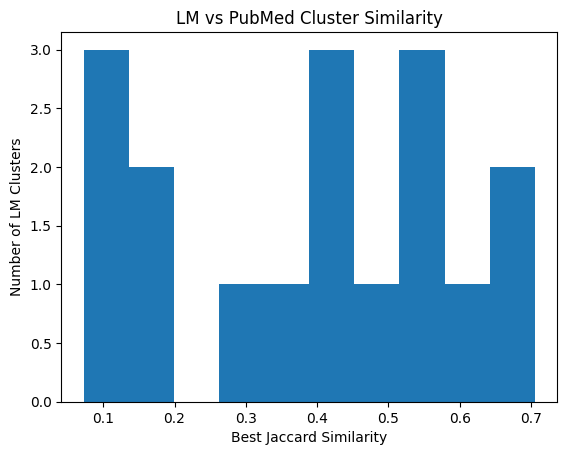

In [29]:
#histogram
import matplotlib.pyplot as plt

plt.hist(best_scores_lm_pm, bins=10)
plt.xlabel("Best Jaccard Similarity")
plt.ylabel("Number of LM Clusters")
plt.title("LM vs PubMed Cluster Similarity")
plt.show()

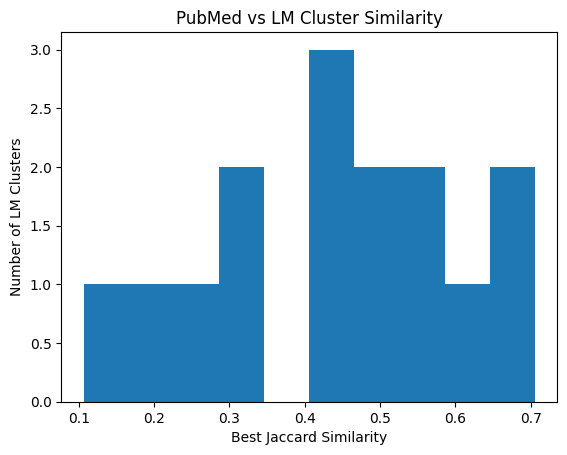

In [30]:
plt.hist(best_scores_pm_lm, bins=10)
plt.xlabel("Best Jaccard Similarity")
plt.ylabel("Number of LM Clusters")
plt.title("PubMed vs LM Cluster Similarity")
plt.show()

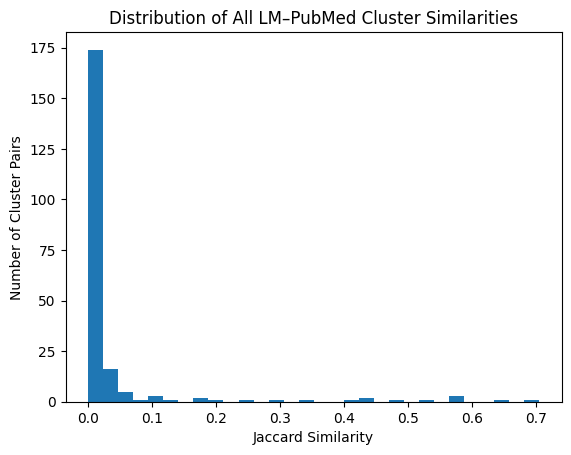

In [31]:
all_pairs = jaccard_lm_pm.flatten()
all_pairs = all_pairs[all_pairs > 0] #no zeros
plt.hist(all_pairs, bins=30)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Cluster Pairs")
plt.title("Distribution of All LM–PubMed Cluster Similarities")
plt.show()

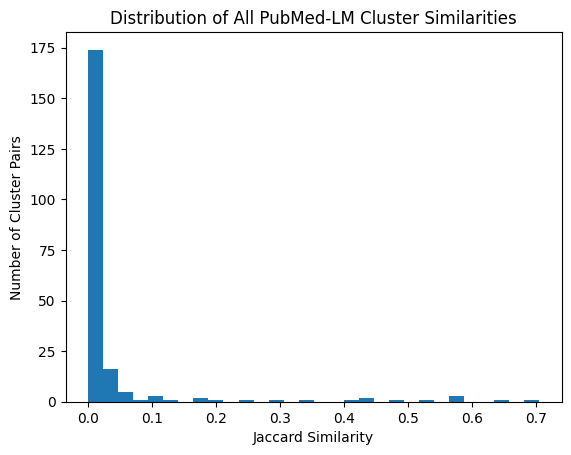

In [32]:
all_pairs = jaccard_pm_lm.flatten()
all_pairs = all_pairs[all_pairs > 0] #no zeros
plt.hist(all_pairs, bins=30)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Cluster Pairs")
plt.title("Distribution of All PubMed-LM Cluster Similarities")
plt.show()

## Kmeans Histogram

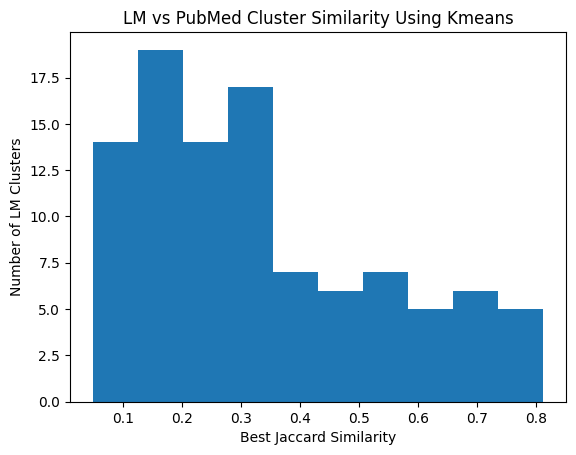

In [33]:
#histogram
import matplotlib.pyplot as plt

plt.hist(best_scores_lm_pm_kmeans, bins=10)
plt.xlabel("Best Jaccard Similarity")
plt.ylabel("Number of LM Clusters")
plt.title("LM vs PubMed Cluster Similarity Using Kmeans")
plt.show()

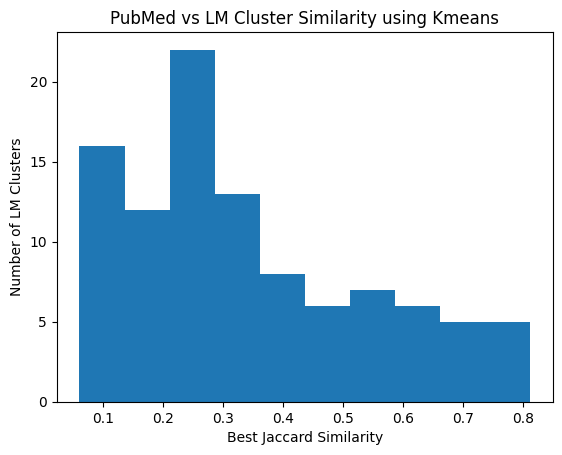

In [34]:
#histogram
import matplotlib.pyplot as plt

plt.hist(best_scores_pm_lm_kmeans, bins=10)
plt.xlabel("Best Jaccard Similarity")
plt.ylabel("Number of LM Clusters")
plt.title("PubMed vs LM Cluster Similarity using Kmeans")
plt.show()

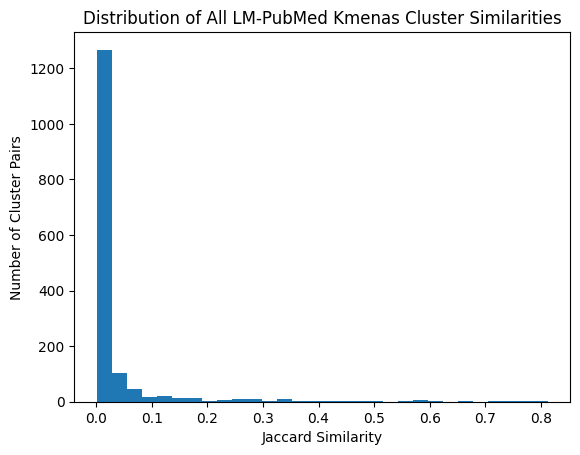

In [35]:
all_pairs = jaccard_lm_pm_kmeans.flatten()
all_pairs = all_pairs[all_pairs > 0] #no zeros
plt.hist(all_pairs, bins=30)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Cluster Pairs")
plt.title("Distribution of All LM-PubMed Kmenas Cluster Similarities")
plt.show()

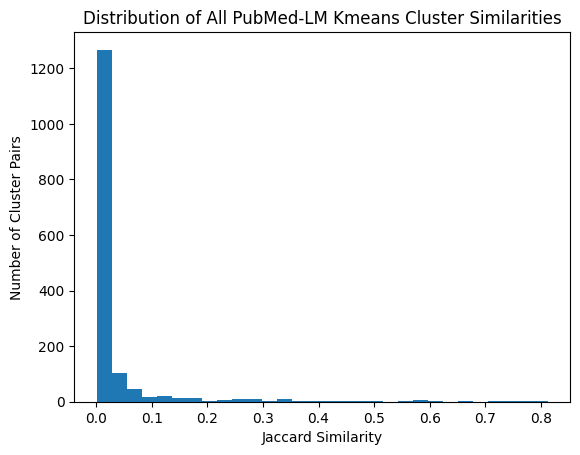

In [36]:
all_pairs = jaccard_pm_lm_kmeans.flatten()
all_pairs = all_pairs[all_pairs > 0] #no zeros
plt.hist(all_pairs, bins=30)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Cluster Pairs")
plt.title("Distribution of All PubMed-LM Kmeans Cluster Similarities")
plt.show()

## Full Jaccard Matrix Heatmap

### Leiden

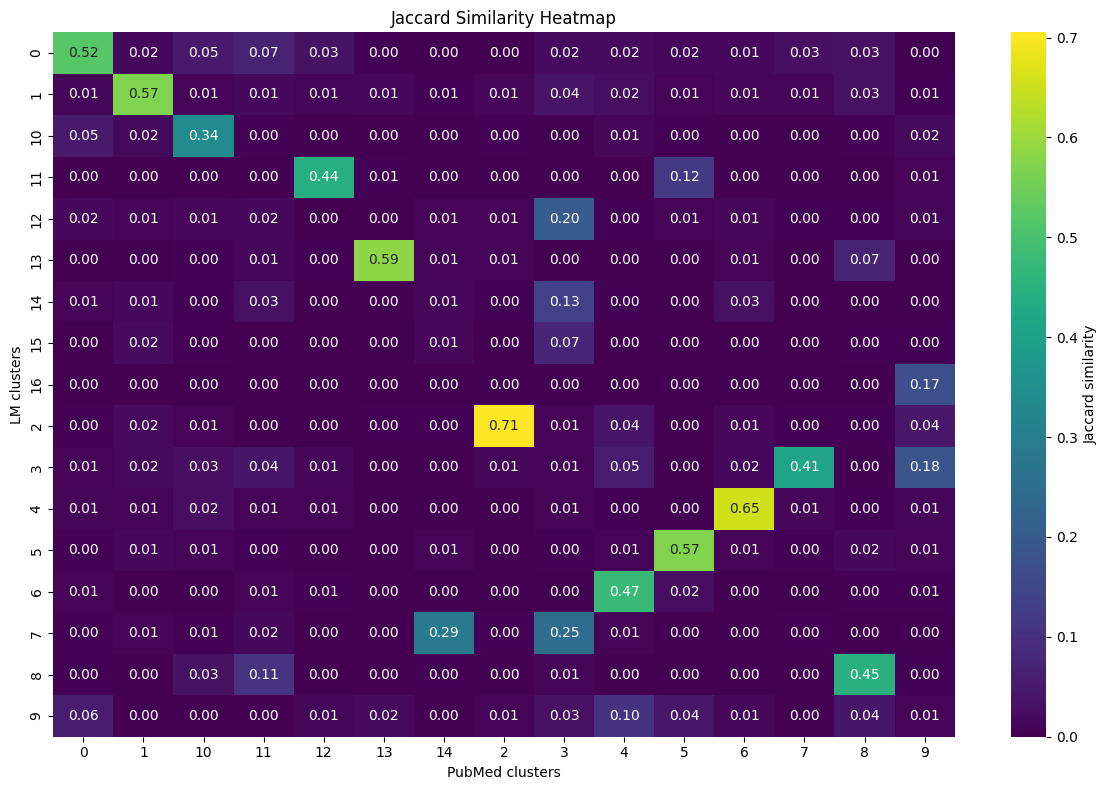

In [37]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    jaccard_lm_pm,
    annot=True,             
    fmt=".2f",             
    cmap="viridis",      
    xticklabels=clusters_pubmed,
    yticklabels=clusters_lm,
    cbar_kws={"label": "Jaccard similarity"}
)

plt.xlabel("PubMed clusters")
plt.ylabel("LM clusters")
plt.title("Jaccard Similarity Heatmap")

plt.tight_layout()
plt.show()

### Kmeans

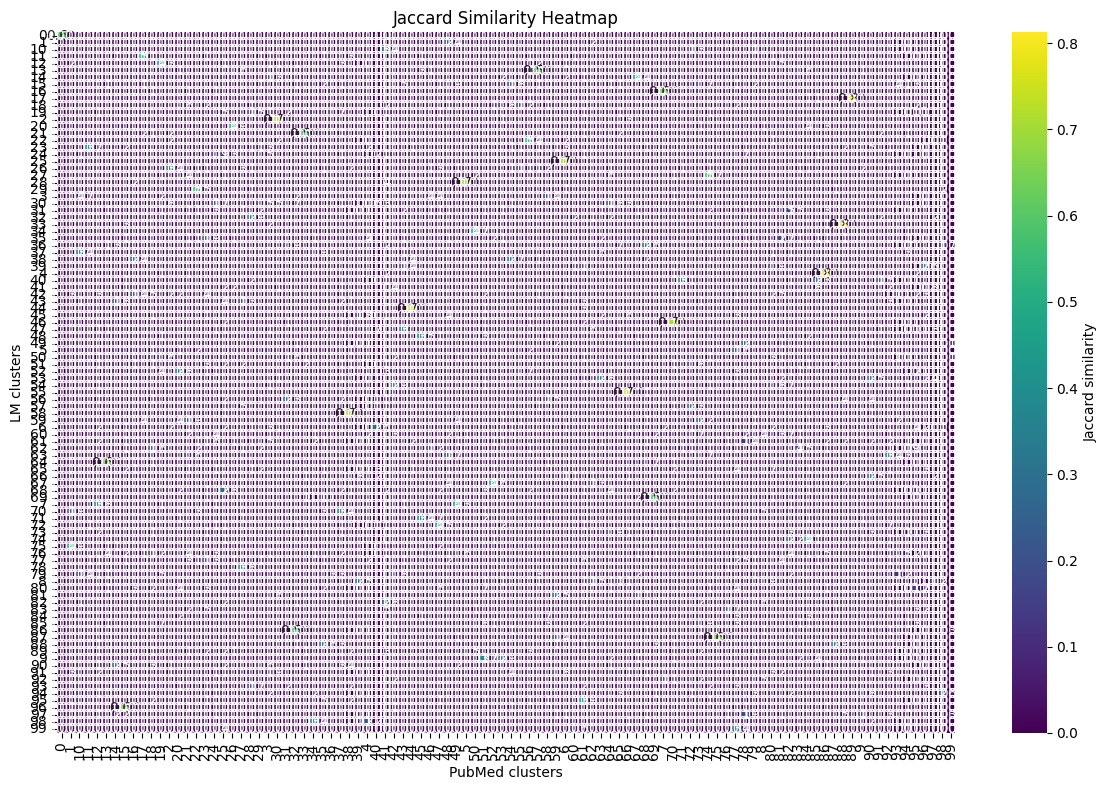

In [38]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    jaccard_lm_pm_kmeans,
    annot=True,             
    fmt=".2f",             
    cmap="viridis",      
    xticklabels=clusters_pubmed_kmeans,
    yticklabels=clusters_lm_kmeans,
    cbar_kws={"label": "Jaccard similarity"}
)

plt.xlabel("PubMed clusters")
plt.ylabel("LM clusters")
plt.title("Jaccard Similarity Heatmap")

plt.tight_layout()
plt.show()

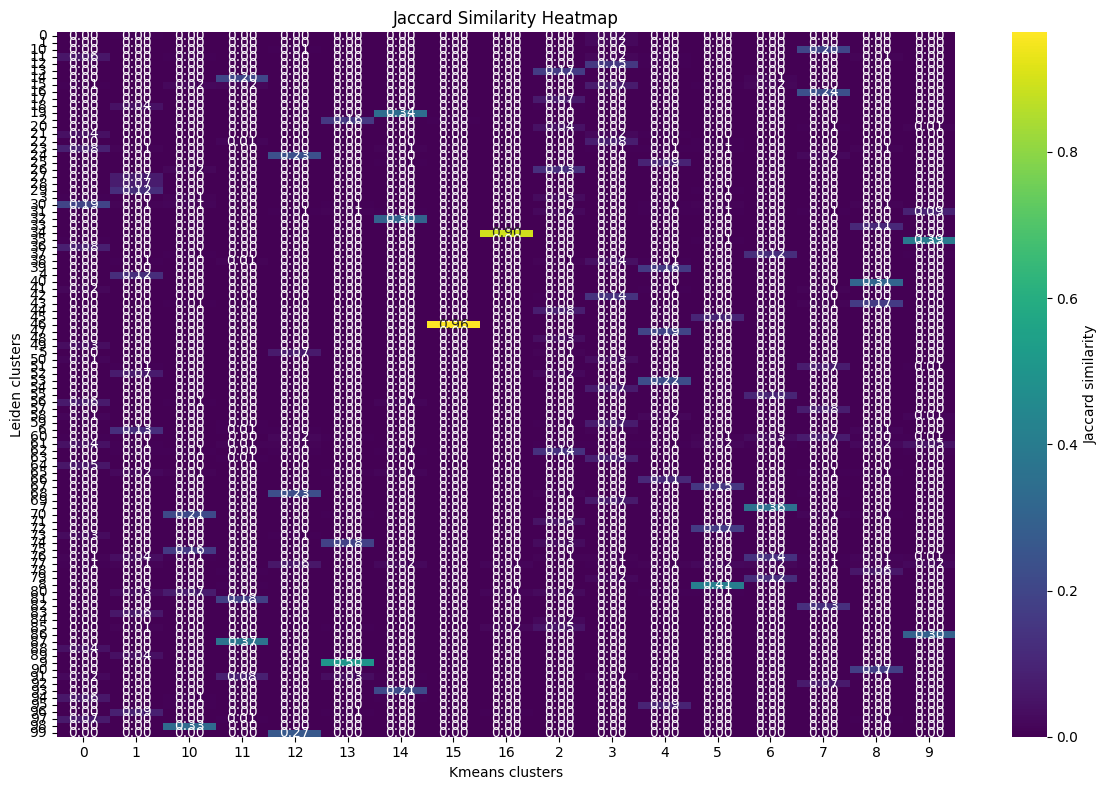

In [39]:
#minilm leiden vs kmeans for LM
import numpy as np

# create empty matrix
jaccard_clusters = np.zeros((len(clusters_lm_kmeans), len(clusters_lm)))

# fill matrix
for i in range(len(clusters_lm_kmeans)):
    c1 = clusters_lm_kmeans[i]
    set1 = set(np.where(labels_lm_kmeans == c1)[0])

    for j in range(len(clusters_lm)):
        c2 = clusters_lm[j]
        set2 = set(np.where(labels_lm == c2)[0])

        intersection = len(set1 & set2)
        union = len(set1 | set2)

        if union > 0:
            jaccard_clusters[i, j] = intersection / union
        else:
            jaccard_clusters[i, j] = 0

# plot

plt.figure(figsize=(12, 8))

sns.heatmap(
    jaccard_clusters,
    annot=True,             
    fmt=".2f",             
    cmap="viridis",      
    xticklabels=clusters_lm,
    yticklabels=clusters_lm_kmeans,
    cbar_kws={"label": "Jaccard similarity"}
)

plt.xlabel("Kmeans clusters")
plt.ylabel("Leiden clusters")
plt.title("Jaccard Similarity Heatmap")

plt.tight_layout()
plt.show()

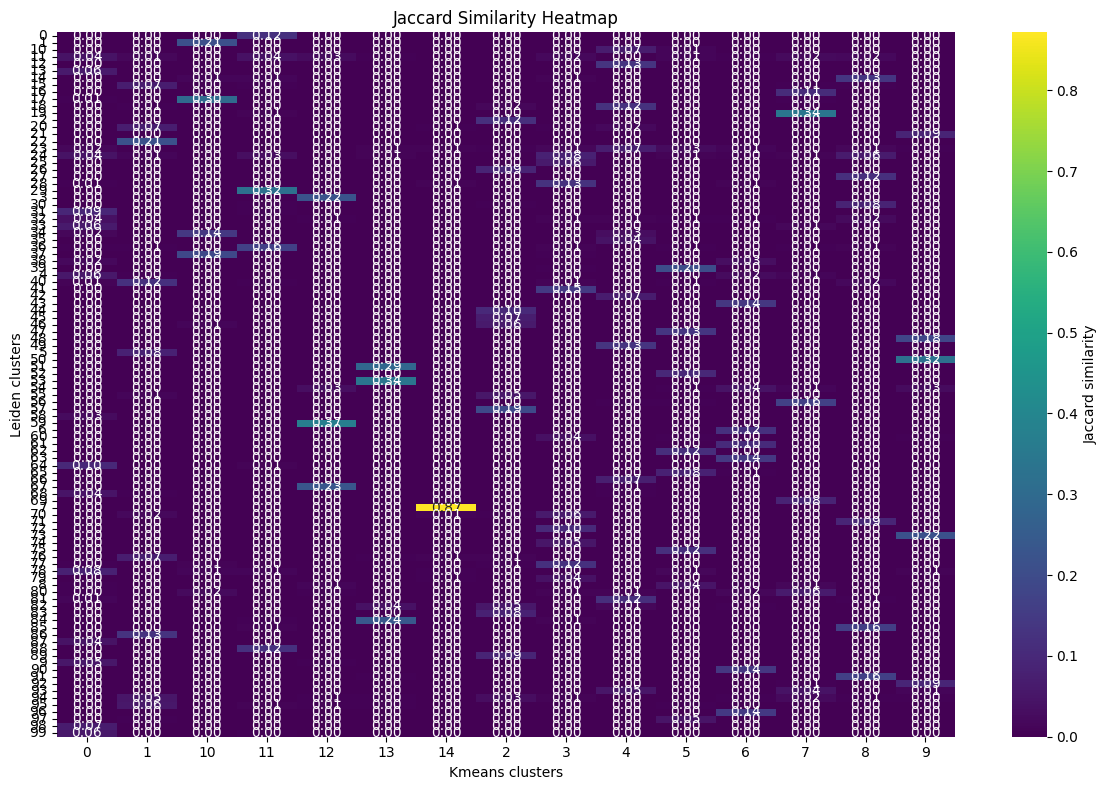

In [40]:
#pubmed leiden vs kmeans for Pubmed
import numpy as np

# create empty matrix
jaccard_clusters_pm = np.zeros((len(clusters_pubmed_kmeans), len(clusters_pubmed)))

# fill matrix
for i in range(len(clusters_pubmed_kmeans)):
    c1 = clusters_pubmed_kmeans[i]
    set1 = set(np.where(labels_pubmed_kmeans == c1)[0])

    for j in range(len(clusters_pubmed)):
        c2 = clusters_pubmed[j]
        set2 = set(np.where(labels_pubmed == c2)[0])

        intersection = len(set1 & set2)
        union = len(set1 | set2)

        if union > 0:
            jaccard_clusters_pm[i, j] = intersection / union
        else:
            jaccard_clusters_pm[i, j] = 0

# plot
plt.figure(figsize=(12, 8))

sns.heatmap(
    jaccard_clusters_pm,
    annot=True,             
    fmt=".2f",             
    cmap="viridis",      
    xticklabels=clusters_pubmed,
    yticklabels=clusters_pubmed_kmeans,
    cbar_kws={"label": "Jaccard similarity"}
)

plt.xlabel("Kmeans clusters")
plt.ylabel("Leiden clusters")
plt.title("Jaccard Similarity Heatmap")

plt.tight_layout()
plt.show()

## KL Divergence (pairwise)

### Euclidean

In [41]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.special import rel_entr

def pairwise_distance_kl_entropy_euclidean(emb_A, emb_B, labels_A, labels_B, cluster_A, cluster_B, bins=30, epsilon=1e-8):
    # shared indices
    idx_A = np.where(labels_A == cluster_A)[0]
    idx_B = np.where(labels_B == cluster_B)[0]

    shared_idx = np.intersect1d(idx_A, idx_B)

    # embeddings
    XA = emb_A[shared_idx]
    XB = emb_B[shared_idx]

    # pairwise distances inside cluster
    dA = pdist(XA, metric="euclidean")
    dB = pdist(XB, metric="euclidean")

    bins = min(bins, int(np.sqrt(len(dA))))
    bins = max(bins, 1)

    # include for both min and max distances (bin edges)
    all_dists = np.concatenate([dA, dB])
    _ , bin_edges = np.histogram(all_dists, bins=bins)

    hist_A, _ = np.histogram(dA, bins=bin_edges)
    hist_B, _ = np.histogram(dB, bins=bin_edges)

    P = hist_A + epsilon
    Q = hist_B + epsilon

    P = P / P.sum()
    Q = Q / Q.sum()

    kl_A_to_B = np.sum(rel_entr(P, Q))
    kl_B_to_A = np.sum(rel_entr(Q, P))

    entropy_A = -np.sum(P * np.log(P))
    entropy_B = -np.sum(Q * np.log(Q))

    return kl_A_to_B, kl_B_to_A, entropy_A, entropy_B, len(shared_idx)

In [42]:
pairwise_distance_kl_entropy_euclidean(emb_lm, emb_pubmed, labels_lm, labels_pubmed, '2', '2')

(0.17754730308947236,
 0.14042312248759517,
 2.5475865369808965,
 2.1817624157714794,
 1098)

In [43]:
import numpy as np
import pandas as pd

clusters_lm = np.unique(labels_lm)
clusters_pubmed = np.unique(labels_pubmed)

results = []

for i in range(len(clusters_lm)):
    cluster_A = clusters_lm[i]

    for j in range(len(clusters_pubmed)):
        cluster_B = clusters_pubmed[j]

        kl1, kl2, entA, entB, n_shared = pairwise_distance_kl_entropy_euclidean(
            emb_lm,
            emb_pubmed,
            labels_lm,
            labels_pubmed,
            cluster_A,
            cluster_B
        )

        j_score = jaccard_lm_pm[i, j]

        results.append({
            "lm_cluster": cluster_A,
            "pm_cluster": cluster_B,
            "jaccard": j_score,
            "kl_lm_to_pm": kl1,
            "kl_pm_to_lm": kl2,
            "entropy_lm": entA,
            "entropy_pm": entB,
            "shared": n_shared
        })

df = pd.DataFrame(results)

df_valid = df[
    (df["jaccard"] > 0.1) &
    (~df["kl_lm_to_pm"].isna())
]

print("Pairs kept:", len(df_valid))

print("Mean KL (LM → PubMed):", df_valid["kl_lm_to_pm"].mean())
print("Mean KL (PubMed → LM):", df_valid["kl_pm_to_lm"].mean())
print("Mean Entropy (LM):", df_valid["entropy_lm"].mean())
print("Mean Entropy (PubMed):", df_valid["entropy_pm"].mean())

Pairs kept: 20
Mean KL (LM → PubMed): 0.11794035302196249
Mean KL (PubMed → LM): 0.11225362348724607
Mean Entropy (LM): 2.54435340671064
Mean Entropy (PubMed): 2.4265482506133282


### Cosine

In [44]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.special import rel_entr

def pairwise_distance_kl_entropy_cosine(emb_A, emb_B, labels_A, labels_B, cluster_A, cluster_B, bins=30, epsilon=1e-8):
    # shared indices
    idx_A = np.where(labels_A == cluster_A)[0]
    idx_B = np.where(labels_B == cluster_B)[0]

    shared_idx = np.intersect1d(idx_A, idx_B)

    # embeddings
    XA = emb_A[shared_idx]
    XB = emb_B[shared_idx]

    # pairwise distances inside cluster
    dA = pdist(XA, metric="cosine")
    dB = pdist(XB, metric="cosine")

    bins = min(bins, int(np.sqrt(len(dA))))
    bins = max(bins, 1)

    # include for both min and max distances 
    all_dists = np.concatenate([dA, dB])
    _ , bin_edges = np.histogram(all_dists, bins=bins)

    hist_A, _ = np.histogram(dA, bins=bin_edges)
    hist_B, _ = np.histogram(dB, bins=bin_edges)

    P = hist_A + epsilon
    Q = hist_B + epsilon

    P = P / P.sum()
    Q = Q / Q.sum()

    kl_A_to_B = np.sum(rel_entr(P, Q))
    kl_B_to_A = np.sum(rel_entr(Q, P))

    entropy_A = -np.sum(P * np.log(P))
    entropy_B = -np.sum(Q * np.log(Q))

    return kl_A_to_B, kl_B_to_A, entropy_A, entropy_B, len(shared_idx)

In [45]:
pairwise_distance_kl_entropy_cosine(emb_lm, emb_pubmed, labels_lm, labels_pubmed, '2', '2')

(0.1817669239999406,
 0.14271433491873117,
 2.842497460779436,
 2.5003290989758122,
 1098)

In [46]:
import numpy as np
import pandas as pd

clusters_lm = np.unique(labels_lm)
clusters_pubmed = np.unique(labels_pubmed)

results = []

for i in range(len(clusters_lm)):
    cluster_A = clusters_lm[i]

    for j in range(len(clusters_pubmed)):
        cluster_B = clusters_pubmed[j]

        kl1, kl2, entA, entB, n_shared = pairwise_distance_kl_entropy_cosine(
            emb_lm,
            emb_pubmed,
            labels_lm,
            labels_pubmed,
            cluster_A,
            cluster_B
        )

        j_score = jaccard_lm_pm[i, j]

        results.append({
            "lm_cluster": cluster_A,
            "pm_cluster": cluster_B,
            "jaccard": j_score,
            "kl_lm_to_pm": kl1,
            "kl_pm_to_lm": kl2,
            "entropy_lm": entA,
            "entropy_pm": entB,
            "shared": n_shared
        })

df = pd.DataFrame(results)

df_valid = df[
    (df["jaccard"] > 0.1) &
    (~df["kl_lm_to_pm"].isna())
]

print("Pairs kept:", len(df_valid))

print("Mean KL (LM → PubMed):", df_valid["kl_lm_to_pm"].mean())
print("Mean KL (PubMed → LM):", df_valid["kl_pm_to_lm"].mean())
print("Mean Entropy (LM):", df_valid["entropy_lm"].mean())
print("Mean Entropy (PubMed):", df_valid["entropy_pm"].mean())

Pairs kept: 20
Mean KL (LM → PubMed): 0.11894290853782383
Mean KL (PubMed → LM): 0.10982463214004863
Mean Entropy (LM): 2.835816083547601
Mean Entropy (PubMed): 2.7321558627387312


## Cluster size vs jaccard

### Leiden

In [47]:
cluster_size_lm = {}
cluster_size_pubmed = {}

labels_lm_int = [int(x) for x in labels_lm]
labels_pubmed_int = [int(x) for x in labels_pubmed]

for label in labels_lm_int:
    if label in cluster_size_lm:
        cluster_size_lm[label] += 1
    else:
        cluster_size_lm[label] = 1

print(cluster_size_lm)

for label in labels_pubmed_int:
    if label in cluster_size_pubmed:
        cluster_size_pubmed[label] += 1
    else:
        cluster_size_pubmed[label] = 1

print(cluster_size_pubmed)

{2: 1444, 6: 709, 8: 587, 4: 862, 0: 2122, 3: 1331, 1: 1455, 12: 408, 9: 502, 5: 752, 16: 105, 7: 653, 13: 400, 14: 291, 11: 423, 10: 445, 15: 135}
{2: 1211, 4: 1206, 8: 722, 1: 1324, 3: 1207, 5: 973, 9: 581, 12: 411, 0: 1702, 6: 929, 13: 352, 7: 765, 10: 546, 11: 439, 14: 256}


### kmeans, gmm, and hdbscan

In [48]:
#cluster sizes
cluster_size_lm_kmeans = {}
cluster_size_pubmed_kmeans = {}
cluster_size_lm_gmm = {}
cluster_size_pubmed_gmm = {}
cluster_size_lm_hdbscan = {}
cluster_size_pubmed_hdbscan = {}

labels_lm_kmeans_int = [int(x) for x in labels_lm_kmeans]
labels_pubmed_kmeans_int = [int(x) for x in labels_pm_kmeans]
labels_lm_gmm_int = [int(x) for x in labels_lm_gmm]
labels_pubmed_gmm_int = [int(x) for x in labels_pm_gmm]
labels_lm_hdbscan_int = [int(x) for x in labels_lm_hdbscan]
labels_pubmed_hdbscan_int = [int(x) for x in labels_pm_hdbscan]

#kmeans
for label in labels_lm_kmeans_int:
    if label in cluster_size_lm_kmeans:
        cluster_size_lm_kmeans[label] += 1
    else:
        cluster_size_lm_kmeans[label] = 1

for label in labels_pubmed_kmeans_int:
    if label in cluster_size_pubmed_kmeans:
        cluster_size_pubmed_kmeans[label] += 1
    else:
        cluster_size_pubmed_kmeans[label] = 1

#GMM
for label in labels_lm_gmm_int:
    if label in cluster_size_lm_gmm:
        cluster_size_lm_gmm[label] += 1
    else:
        cluster_size_lm_gmm[label] = 1

for label in labels_pubmed_gmm_int:
    if label in cluster_size_pubmed_gmm:
        cluster_size_pubmed_gmm[label] += 1
    else:
        cluster_size_pubmed_gmm[label] = 1

# HDSCAN
for label in labels_lm_hdbscan_int:
    if label in cluster_size_lm_hdbscan:
        cluster_size_lm_hdbscan[label] += 1
    else:
        cluster_size_lm_hdbscan[label] = 1

for label in labels_pubmed_hdbscan_int:
    if label in cluster_size_pubmed_hdbscan:
        cluster_size_pubmed_hdbscan[label] += 1
    else:
        cluster_size_pubmed_hdbscan[label] = 1

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Slope: 9.625217393778782e-05
R²: 0.04375152500499805
p-value: 0.37613125512780565


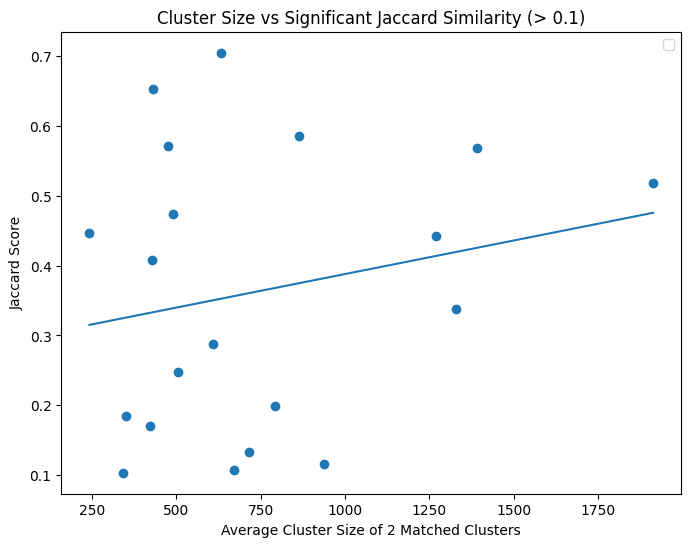

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

# use the exact heatmap order Leiden
lm_order = np.arange(jaccard_lm_pm.shape[0])
pm_order = np.arange(jaccard_lm_pm.shape[1])

jaccard_df = pd.DataFrame(jaccard_lm_pm, index=lm_order, columns=pm_order)

x_lm = []
x_pm = []
y = []
labels = []

for lm_cluster in jaccard_df.index:
    for pm_cluster in jaccard_df.columns:
        score = jaccard_df.loc[lm_cluster, pm_cluster]

        if lm_cluster in cluster_size_lm and pm_cluster in cluster_size_pubmed:
            if score > 0.1:
                x_lm.append(cluster_size_lm[lm_cluster])
                x_pm.append(cluster_size_pubmed[pm_cluster])
                y.append(score)
                labels.append((lm_cluster, pm_cluster))

plt.figure(figsize=(8, 6))
x_lm = np.array(x_lm)
x_pm = np.array(x_pm)
delta = abs(x_lm - x_pm)
avg = np.mean(np.stack([x_lm, x_pm]), axis=0)

#print(np.stack([x_lm, x_pm]).shape)
#print(avg.shape)

# fit regression
slope, intercept, r_value, p_value, std_err = linregress(avg, y)

# regression line
x_line = np.linspace(avg.min(), avg.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(avg, y)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

#plt.yscale("log")
#plt.xscale("log")
plt.xlabel("Average Cluster Size of 2 Matched Clusters")
plt.ylabel("Jaccard Score")
plt.title("Cluster Size vs Significant Jaccard Similarity (> 0.1)")
plt.legend()
plt.show()

In [50]:
# use the exact heatmap order kmeans
lm_order_kmeans = np.arange(jaccard_lm_pm_kmeans.shape[0])
pm_order_kmeans = np.arange(jaccard_lm_pm_kmeans.shape[1])

jaccard_df_kmeans = pd.DataFrame(
    jaccard_lm_pm_kmeans, index=lm_order_kmeans, columns=pm_order_kmeans
)

x_lm_kmeans = []
x_pm_kmeans = []
y_kmeans = []
labels_kmeans = []

for lm_cluster in jaccard_df_kmeans.index:
    for pm_cluster in jaccard_df_kmeans.columns:
        score = jaccard_df_kmeans.loc[lm_cluster, pm_cluster]

        if lm_cluster in cluster_size_lm_kmeans and pm_cluster in cluster_size_pubmed_kmeans:
            if score > 0.1:
                x_lm_kmeans.append(cluster_size_lm_kmeans[lm_cluster])
                x_pm_kmeans.append(cluster_size_pubmed_kmeans[pm_cluster])
                y_kmeans.append(score)
                labels_kmeans.append((lm_cluster, pm_cluster))

x_lm_kmeans = np.array(x_lm_kmeans)
x_pm_kmeans = np.array(x_pm_kmeans)
delta_kmeans = abs(x_lm_kmeans - x_pm_kmeans)
avg_kmeans = np.mean(np.stack([x_lm_kmeans, x_pm_kmeans]), axis=0)

In [51]:
# use the exact heatmap order GMM
lm_order_gmm = np.arange(jaccard_lm_pm_gmm.shape[0])
pm_order_gmm = np.arange(jaccard_lm_pm_gmm.shape[1])

jaccard_df_gmm = pd.DataFrame(
    jaccard_lm_pm_gmm, index=lm_order_gmm, columns=pm_order_gmm
)

x_lm_gmm = []
x_pm_gmm = []
y_gmm = []
labels_gmm = []

for lm_cluster in jaccard_df_gmm.index:
    for pm_cluster in jaccard_df_gmm.columns:
        score = jaccard_df_gmm.loc[lm_cluster, pm_cluster]

        if lm_cluster in cluster_size_lm_gmm and pm_cluster in cluster_size_pubmed_gmm:
            if score > 0.1:
                x_lm_gmm.append(cluster_size_lm_gmm[lm_cluster])
                x_pm_gmm.append(cluster_size_pubmed_gmm[pm_cluster])
                y_gmm.append(score)
                labels_gmm.append((lm_cluster, pm_cluster))

x_lm_gmm = np.array(x_lm_gmm)
x_pm_gmm = np.array(x_pm_gmm)
delta_gmm = abs(x_lm_gmm - x_pm_gmm)
avg_gmm = np.mean(np.stack([x_lm_gmm, x_pm_gmm]), axis=0)

In [52]:
# use the exact heatmap order HDBSCAN
lm_order_hdbscan = np.arange(jaccard_lm_pm_hdbscan.shape[0])
pm_order_hdbscan = np.arange(jaccard_lm_pm_hdbscan.shape[1])

jaccard_df_hdbscan = pd.DataFrame(
    jaccard_lm_pm_hdbscan, index=lm_order_hdbscan, columns=pm_order_hdbscan
)

x_lm_hdbscan = []
x_pm_hdbscan = []
y_hdbscan = []
labels_hdbscan = []

for lm_cluster in jaccard_df_hdbscan.index:
    for pm_cluster in jaccard_df_hdbscan.columns:
        score = jaccard_df_hdbscan.loc[lm_cluster, pm_cluster]

        if lm_cluster in cluster_size_lm_hdbscan and pm_cluster in cluster_size_pubmed_hdbscan:
            if score > 0.1:
                x_lm_hdbscan.append(cluster_size_lm_hdbscan[lm_cluster])
                x_pm_hdbscan.append(cluster_size_pubmed_hdbscan[pm_cluster])
                y_hdbscan.append(score)
                labels_hdbscan.append((lm_cluster, pm_cluster))

x_lm_hdbscan = np.array(x_lm_hdbscan)
x_pm_hdbscan = np.array(x_pm_hdbscan)
delta_hdbscan = abs(x_lm_hdbscan - x_pm_hdbscan)
avg_hdbscan = np.mean(np.stack([x_lm_hdbscan, x_pm_hdbscan]), axis=0)

Slope: 9.625217393778782e-05
R²: 0.04375152500499805
p-value: 0.37613125512780565


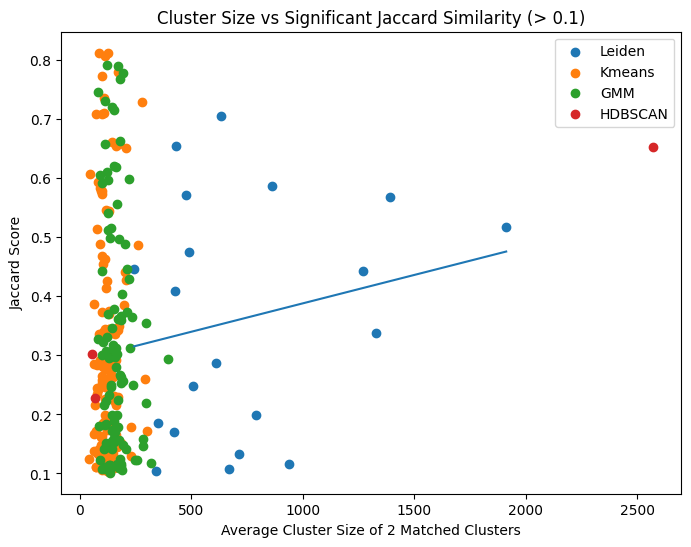

In [53]:
plt.figure(figsize=(8, 6))

# fit regression
slope, intercept, r_value, p_value, std_err = linregress(avg, y)

# regression line
x_line = np.linspace(avg.min(), avg.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(avg, y)
plt.scatter(avg_kmeans, y_kmeans)
plt.scatter(avg_gmm, y_gmm)
plt.scatter(avg_hdbscan, y_hdbscan)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

#plt.yscale("log")
#plt.xscale("log")
plt.xlabel("Average Cluster Size of 2 Matched Clusters")
plt.ylabel("Jaccard Score")
plt.title("Cluster Size vs Significant Jaccard Similarity (> 0.1)")
plt.legend(['Leiden', 'Kmeans', 'GMM', 'HDBSCAN'])
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Slope: -0.0003609757864512747
R²: 0.2427471633669696
p-value: 0.027308332006924244


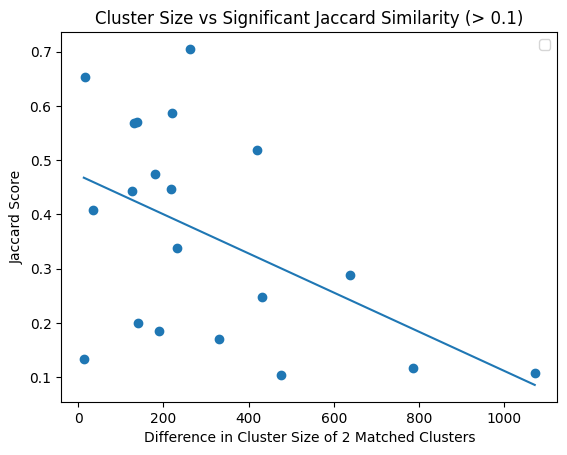

In [54]:
# fit regression
slope, intercept, r_value, p_value, std_err = linregress(delta, y)

# regression line
x_line = np.linspace(delta.min(), delta.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(delta, y)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

plt.xlabel("Difference in Cluster Size of 2 Matched Clusters")
plt.ylabel("Jaccard Score")
plt.title("Cluster Size vs Significant Jaccard Similarity (> 0.1)")
plt.legend()
plt.show()

### Leiden vs kmeans

In [55]:
cluster_size_leiden = {}
cluster_size_kmeans = {}

labels_leiden_int = [int(x) for x in labels_lm]
labels_kmeans_int = [int(x) for x in labels_lm_kmeans]

for label in labels_leiden_int:
    if label in cluster_size_leiden:
        cluster_size_leiden[label] += 1
    else:
        cluster_size_leiden[label] = 1

print(cluster_size_leiden)

for label in labels_kmeans_int:
    if label in cluster_size_kmeans:
        cluster_size_kmeans[label] += 1
    else:
        cluster_size_kmeans[label] = 1

print(cluster_size_kmeans)

{2: 1444, 6: 709, 8: 587, 4: 862, 0: 2122, 3: 1331, 1: 1455, 12: 408, 9: 502, 5: 752, 16: 105, 7: 653, 13: 400, 14: 291, 11: 423, 10: 445, 15: 135}
{62: 235, 74: 126, 40: 182, 61: 220, 7: 267, 47: 168, 36: 173, 76: 266, 42: 194, 79: 134, 28: 109, 77: 149, 37: 102, 35: 240, 45: 75, 8: 312, 27: 102, 83: 88, 69: 87, 88: 93, 34: 94, 99: 114, 6: 231, 60: 118, 52: 142, 25: 82, 85: 95, 3: 57, 10: 132, 9: 202, 84: 32, 22: 125, 73: 69, 86: 162, 19: 99, 41: 54, 15: 164, 4: 177, 87: 155, 94: 136, 56: 148, 14: 100, 67: 119, 66: 92, 75: 73, 24: 123, 53: 204, 38: 91, 30: 492, 91: 132, 12: 224, 82: 85, 72: 134, 78: 37, 96: 131, 98: 155, 50: 74, 63: 121, 80: 133, 57: 58, 13: 241, 31: 117, 93: 66, 59: 105, 20: 75, 90: 117, 48: 51, 64: 116, 39: 137, 54: 98, 17: 96, 70: 123, 11: 177, 29: 184, 2: 69, 46: 134, 0: 34, 21: 117, 1: 32, 44: 112, 18: 76, 71: 67, 81: 76, 65: 58, 43: 117, 68: 113, 58: 56, 49: 73, 5: 41, 16: 163, 32: 90, 95: 87, 89: 63, 97: 154, 51: 65, 23: 241, 55: 69, 92: 44, 26: 219, 33: 63}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Slope: -3.062057900169016e-05
R²: 0.0018111579294043014
p-value: 0.7788453562912019


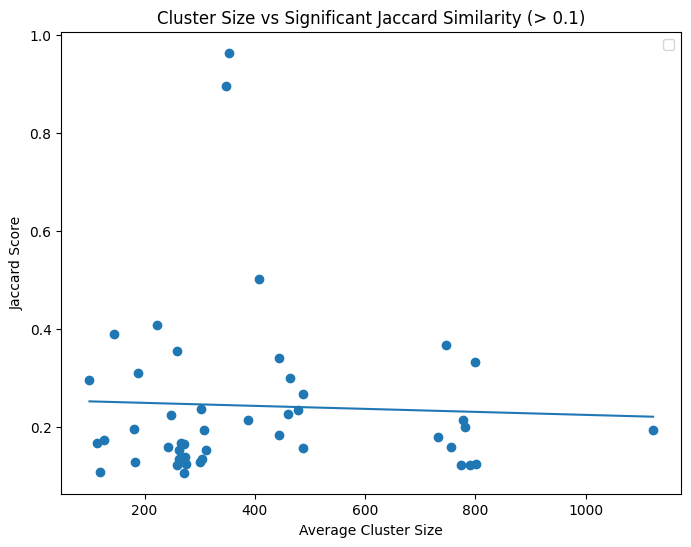

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# use the exact heatmap order
kmeans_order = np.arange(jaccard_clusters.shape[0])
leiden_order = np.arange(jaccard_clusters.shape[1])

jaccard_df_clusters = pd.DataFrame(
    jaccard_clusters,
    index=kmeans_order,
    columns=leiden_order
)

x_leiden = []
x_kmeans = []
y = []
labels = []

for kmeans_cluster in jaccard_df_clusters.index:
    for leiden_cluster in jaccard_df_clusters.columns:
        score = jaccard_df_clusters.loc[kmeans_cluster, leiden_cluster]

        if score > 0.1:
            if leiden_cluster in cluster_size_leiden and kmeans_cluster in cluster_size_kmeans:
                x_leiden.append(cluster_size_leiden[leiden_cluster])
                x_kmeans.append(cluster_size_kmeans[kmeans_cluster])
                y.append(score)
                labels.append((kmeans_cluster, leiden_cluster))

plt.figure(figsize=(8, 6))
x_leiden = np.array(x_leiden)
x_kmeans = np.array(x_kmeans)
delta = abs(x_leiden - x_kmeans)

avg = np.mean(np.stack([x_leiden, x_kmeans]), axis=0)

# fit regression
slope, intercept, r_value, p_value, std_err = linregress(avg, y)

# regression line
x_line = np.linspace(avg.min(), avg.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(avg, y)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

#plt.scatter(x_leiden, y, label="Leiden Size", marker="o")
#plt.scatter(x_kmeans, y, label="Kmeans Size", marker="x")

#for i in range(len(labels)):
#    kmeans_cluster, leiden_cluster = labels[i]
#    plt.text(x_leiden[i], y[i], f"K{kmeans_cluster}->L{leiden_cluster}", fontsize=8)

plt.xlabel("Average Cluster Size")
plt.ylabel("Jaccard Score")
plt.title("Cluster Size vs Significant Jaccard Similarity (> 0.1)")
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Slope: -4.377417671006178e-06
R²: 0.0001400112915614163
p-value: 0.9377907354976562


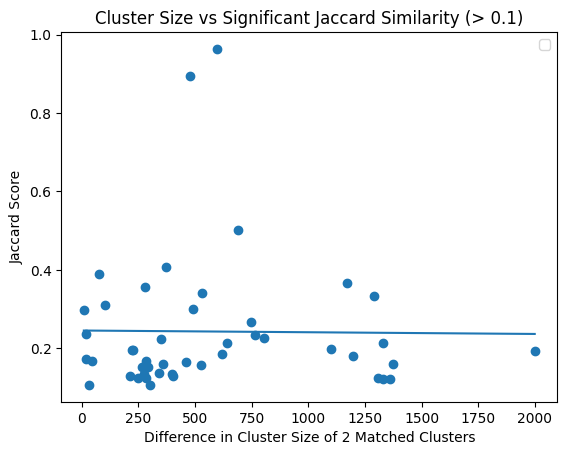

In [57]:
# fit regression
slope, intercept, r_value, p_value, std_err = linregress(delta, y)

# regression line
x_line = np.linspace(delta.min(), delta.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(delta, y)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

plt.xlabel("Difference in Cluster Size of 2 Matched Clusters")
plt.ylabel("Jaccard Score")
plt.title("Cluster Size vs Significant Jaccard Similarity (> 0.1)")
plt.legend()
plt.show()

## Scatter plot of pairwise KL and Jaccard

Slope: 0.04961930030685895
R²: 0.004663255421606547
p-value: 0.7748298219557437


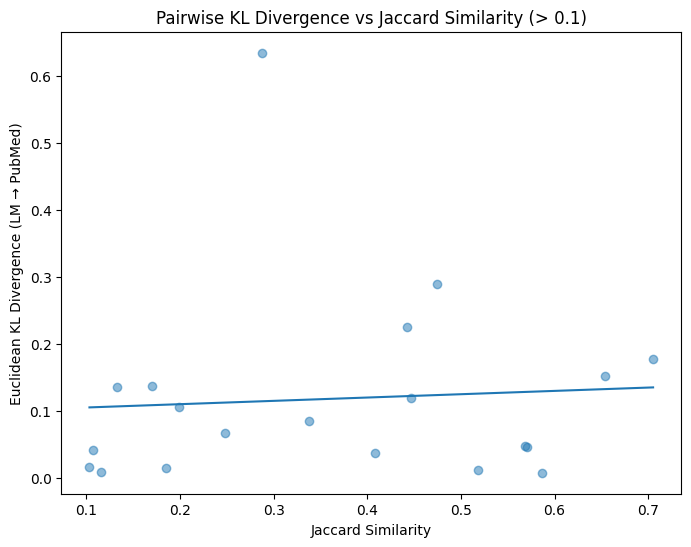

In [58]:
# euclidean
import numpy as np
import matplotlib.pyplot as plt

#create KL matrix that matches Jaccard
kl_lm_to_pm = np.full((len(clusters_lm), len(clusters_pubmed)), np.nan)
kl_pm_to_lm = np.full((len(clusters_lm), len(clusters_pubmed)), np.nan)
shared_counts = np.zeros((len(clusters_lm), len(clusters_pubmed)), dtype=int)

for i in range(len(clusters_lm)):
    cluster_A = clusters_lm[i]

    for j in range(len(clusters_pubmed)):
        cluster_B = clusters_pubmed[j]

        kl1, kl2, _, _, n_shared = pairwise_distance_kl_entropy_euclidean(
            emb_lm,
            emb_pubmed,
            labels_lm,
            labels_pubmed,
            cluster_A,
            cluster_B
        )

        kl_lm_to_pm[i, j] = kl1
        kl_pm_to_lm[i, j] = kl2
        shared_counts[i, j] = n_shared

# returns matrix full of values for every cluster pair
    # kl_lm_to_pm tells you, for every LM–PubMed pair, how different the LM internal distance distribution is from the PubMed one
    # kl_pm_to_lm gives the reverse direction
    # shared_counts tells you whether that KL value is trustworthy, because KL based on 2 shared points is much less meaningful than KL based on 200 shared points

#scatter plot
x = []
y = []

for i in range(len(clusters_lm)):
    for j in range(len(clusters_pubmed)):
        j_score = jaccard_lm_pm[i, j]
        kl_score = kl_lm_to_pm[i, j]

        if not np.isnan(kl_score):
            x.append(j_score)
            y.append(kl_score)

plt.figure(figsize=(8, 6))

x_range = []
y_range = []
for i in range(len(x)):
    if x[i] > 0.1:
        x_range.append(x[i])
        y_range.append(y[i])

npx_range = np.array(x_range)
npy_range = np.array(y_range)

# fit regression
slope, intercept, r_value, p_value, std_err = linregress(npx_range, npy_range)

# regression line
x_line = np.linspace(npx_range.min(), npx_range.max(), 100)
y_line = slope * x_line + intercept

plt.scatter(npx_range, npy_range, alpha=0.5)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

#labels
#for i in range(len(x)):
#    if x[i] > 0.09 or y[i] > 3:
#        lm_cluster, pm_cluster = labels[i]
#        plt.text(x[i], y[i], f"{lm_cluster}->{pm_cluster}", fontsize=8)

plt.xlabel("Jaccard Similarity")
plt.ylabel("Euclidean KL Divergence (LM → PubMed)")
plt.title("Pairwise KL Divergence vs Jaccard Similarity (> 0.1)")

plt.show()

Slope: 0.05220600397920844
R²: 0.005302341210202494
p-value: 0.7603013239974933


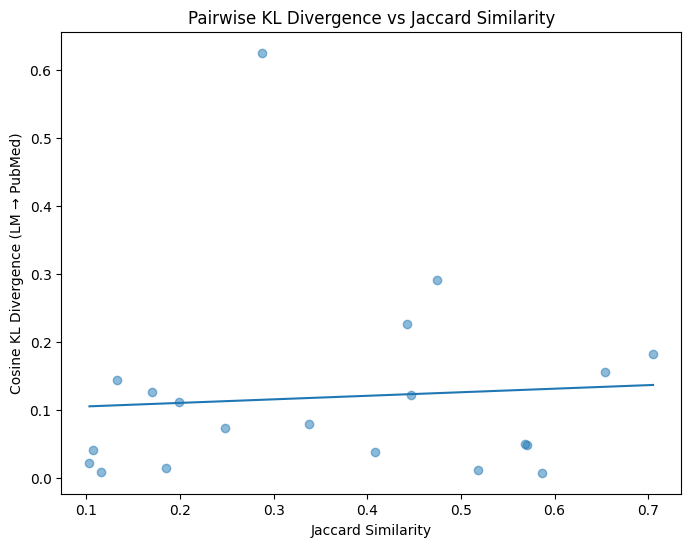

In [59]:
# cosine
import numpy as np
import matplotlib.pyplot as plt

#create KL matrix that matches Jaccard
kl_lm_to_pm = np.full((len(clusters_lm), len(clusters_pubmed)), np.nan)
kl_pm_to_lm = np.full((len(clusters_lm), len(clusters_pubmed)), np.nan)
shared_counts = np.zeros((len(clusters_lm), len(clusters_pubmed)), dtype=int)

for i in range(len(clusters_lm)):
    cluster_A = clusters_lm[i]

    for j in range(len(clusters_pubmed)):
        cluster_B = clusters_pubmed[j]

        kl1, kl2, _, _, n_shared = pairwise_distance_kl_entropy_cosine(
            emb_lm,
            emb_pubmed,
            labels_lm,
            labels_pubmed,
            cluster_A,
            cluster_B
        )

        kl_lm_to_pm[i, j] = kl1
        kl_pm_to_lm[i, j] = kl2
        shared_counts[i, j] = n_shared

#scatter plot
x = []
y = []

for i in range(len(clusters_lm)):
    for j in range(len(clusters_pubmed)):
        j_score = jaccard_lm_pm[i, j]
        kl_score = kl_lm_to_pm[i, j]

        if not np.isnan(kl_score):
            x.append(j_score)
            y.append(kl_score)

x_range = []
y_range = []
for i in range(len(x)):
    if x[i] > 0.1:
        x_range.append(x[i])
        y_range.append(y[i])

npx_range = np.array(x_range)
npy_range = np.array(y_range)

# fit regression
slope, intercept, r_value, p_value, std_err = linregress(npx_range, npy_range)

# regression line
x_line = np.linspace(npx_range.min(), npx_range.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.scatter(npx_range, npy_range, alpha=0.5)
plt.plot(x_line, y_line)

print("Slope:", slope)
print("R²:", r_value**2)
print("p-value:", p_value)

#labels
#for i in range(len(x)):
#    if x[i] > 0.3 or y[i] > 5:
#        lm_cluster, pm_cluster = labels[i]
#        plt.text(x[i], y[i], f"{lm_cluster}->{pm_cluster}", fontsize=8)

plt.xlabel("Jaccard Similarity")
plt.ylabel("Cosine KL Divergence (LM → PubMed)")
plt.title("Pairwise KL Divergence vs Jaccard Similarity")

plt.show()

## Jaccard vs Entropy

In [60]:
pairs = []

for i in range(len(clusters_lm)):
    j = np.argmax(jaccard_lm_pm[i])
    score = jaccard_lm_pm[i, j]

    if score > 0.1:
        pairs.append((i, j, score))


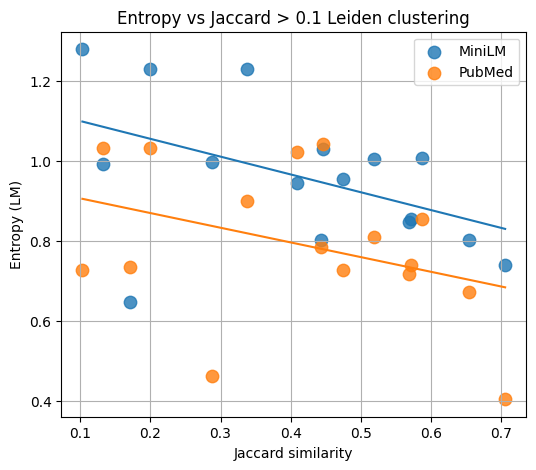

Slope LM: -0.44556161835299585
R value LM: -0.4735939595586793
R^2 LM: 0.22429123853046795
P value LM: 0.06387782109611674

Slope PubMed: -0.3674044608831203
R value PubMed: -0.3664925743202042
R^2 PubMed: 0.13431680703185042
P value PubMed: 0.16265312408097107


In [87]:
labels_lm = np.array(labels_lm).astype(int)
clusters_lm = np.array(clusters_lm).astype(int)

labels_pm = np.array(labels_pubmed).astype(int)
clusters_pm = np.array(clusters_pubmed).astype(int)

labels_lm_kmeans = np.array(labels_lm_kmeans).astype(int)
clusters_lm_kmeans = np.array(clusters_lm_kmeans).astype(int)

labels_pm_kmeans = np.array(labels_pm_kmeans).astype(int)
clusters_pubmed_kmeans = np.array(clusters_pubmed_kmeans).astype(int)

labels_lm_gmm = np.array(labels_lm_gmm).astype(int)
clusters_lm_gmm = np.array(clusters_lm_gmm).astype(int)

labels_pm_gmm = np.array(labels_pubmed_gmm).astype(int)
clusters_pm_gmm = np.array(clusters_pubmed_gmm).astype(int)

labels_lm_hdbscan = np.array(labels_lm_hdbscan).astype(int)
clusters_lm_hdbscan = np.array(clusters_lm_hdbscan).astype(int)

labels_pm_hdbscan = np.array(labels_pubmed_hdbscan).astype(int)
clusters_pm_hdbscan = np.array(clusters_pubmed_hdbscan).astype(int)

entropy_cluster_lm = {}
for c in np.unique(labels_lm):
    idx = np.where(labels_lm == c)[0]
    entropy_cluster_lm[c] = np.mean(entropy_lm[idx])

entropy_cluster_lm_hdbscan = {}
for c in np.unique(labels_lm_hdbscan):
    idx = np.where(labels_lm_hdbscan == c)[0]
    entropy_cluster_lm_hdbscan[c] = np.mean(entropy_lm_hdbscan[idx])

entropy_cluster_lm_kmeans = {}
for c in np.unique(labels_lm_kmeans):
    idx = np.where(labels_lm_kmeans == c)[0]
    entropy_cluster_lm_kmeans[c] = np.mean(entropy_lm_kmeans[idx])

entropy_cluster_lm_gmm = {}
for c in np.unique(labels_lm_gmm):
    idx = np.where(labels_lm_gmm == c)[0]
    entropy_cluster_lm_gmm[c] = np.mean(entropy_lm_gmm[idx])

entropy_cluster_pm = {}
for c in np.unique(labels_pm):
    idx = np.where(labels_pm == c)[0]
    entropy_cluster_pm[c] = np.mean(entropy_pubmed[idx])

entropy_cluster_pubmed_hdbscan = {}
for c in np.unique(labels_pm_hdbscan):
    idx = np.where(labels_pm_hdbscan == c)[0]
    entropy_cluster_pubmed_hdbscan[c] = np.mean(entropy_pubmed_hdbscan[idx])

entropy_cluster_pubmed_kmeans = {}
for c in np.unique(labels_pm_kmeans):
    idx = np.where(labels_pm_kmeans == c)[0]
    entropy_cluster_pubmed_kmeans[c] = np.mean(entropy_pubmed_kmeans[idx])

entropy_cluster_pubmed_gmm = {}
for c in np.unique(labels_pm_gmm):
    idx = np.where(labels_pm_gmm == c)[0]
    entropy_cluster_pubmed_gmm[c] = np.mean(entropy_pubmed_gmm[idx])

x = []
y_lm = []
y_pm = []

for i, j, score in pairs:
    x.append(score)
    y_lm.append(entropy_cluster_lm[clusters_lm[i]])
    y_pm.append(entropy_cluster_pm[clusters_pm[j]])

x = np.array(x, dtype=float)
y_lm = np.array(y_lm, dtype=float)
y_pm = np.array(y_pm, dtype=float)

plt.figure(figsize=(6, 5))
plt.scatter(x, y_lm, s=80, alpha=0.8)
plt.scatter(x, y_pm, s=80, alpha=0.8)

# regression
slope, intercept, r_value, p_value, std_err = linregress(x, y_lm)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x, y_pm)

# line
x_line = np.linspace(min(x), max(x), 100)
y_line_lm = slope * x_line + intercept
y_line_pm = slope_pm * x_line + intercept_pm

plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')

plt.xlabel("Jaccard similarity")
plt.ylabel("Entropy (LM)")
plt.title("Entropy vs Jaccard > 0.1 Leiden clustering")
plt.legend(["MiniLM", "PubMed"])
plt.grid(True)
plt.show()

print("Slope LM:", slope)
print("R value LM:", r_value)
print("R^2 LM:", r_value**2)
print("P value LM:", p_value)

print("\nSlope PubMed:", slope_pm)
print("R value PubMed:", r_value_pm)
print("R^2 PubMed:", r_value_pm**2)
print("P value PubMed:", p_value_pm)

In [ ]:
pairs = []

for i in range(len(clusters_pm)):
    j = np.argmax(jaccard_pm_lm[i])
    score = jaccard_pm_lm[i, j]

    if score > 0.1:
        pairs.append((i, j, score))

x = []
y_lm = []
y_pm = []

for i, j, score in pairs:
    x.append(score)
    y_lm.append(entropy_cluster_pm[clusters_pm[i]])
    y_pm.append(entropy_cluster_lm[clusters_lm[j]])

x = np.array(x, dtype=float)
y_pm = np.array(y_pm, dtype=float)
y_lm = np.array(y_lm, dtype=float)

plt.figure(figsize=(6, 5))
plt.scatter(x, y_pm, s=80, alpha=0.8)
plt.scatter(x, y_lm, s=80, alpha=0.8)

# regression
slope, intercept, r_value, p_value, std_err = linregress(x, y_lm)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x, y_pm)

# line
x_line = np.linspace(min(x), max(x), 100)
y_line_lm = slope * x_line + intercept
y_line_pm = slope_pm * x_line + intercept_pm

plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')

plt.xlabel("Jaccard similarity")
plt.ylabel("Entropy (LM)")
plt.title("Entropy vs Jaccard > 0.1 Leiden clustering")
plt.legend(["MiniLM", "PubMed"])
plt.grid(True)
plt.show()

print("Slope LM:", slope)
print("R value LM:", r_value)
print("R^2 LM:", r_value**2)
print("P value LM:", p_value)

print("\nSlope PubMed:", slope_pm)
print("R value PubMed:", r_value_pm)
print("R^2 PubMed:", r_value_pm**2)
print("P value PubMed:", p_value_pm)

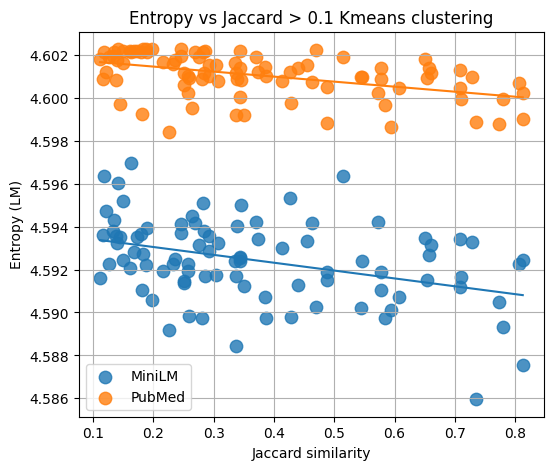

Slope LM: -0.0036608850140668527
R value LM: -0.3849491481579247
R^2 LM: 0.14818584666751186
P value LM: 0.00017942463757147068

Slope PubMed: -0.002340787617767434
R value PubMed: -0.4681516744186444
R^2 PubMed: 0.21916599026098044
P value PubMed: 3.272506470866572e-06


In [74]:
pairs_kmeans = []

for i in range(len(clusters_lm_kmeans)):
    j = np.argmax(jaccard_lm_pm_kmeans[i])
    score = jaccard_lm_pm_kmeans[i, j]

    if score > 0.1:
        pairs_kmeans.append((i, j, score))

x = []
y_lm = []
y_pm = []

for i, j, score in pairs_kmeans:
    x.append(score)
    y_lm.append(entropy_cluster_lm_kmeans[clusters_lm_kmeans[i]])
    y_pm.append(entropy_cluster_pubmed_kmeans[clusters_pubmed_kmeans[j]])

x = np.array(x, dtype=float)
y_lm = np.array(y_lm, dtype=float)
y_pm = np.array(y_pm, dtype=float)

plt.figure(figsize=(6, 5))
plt.scatter(x, y_lm, s=80, alpha=0.8)
plt.scatter(x, y_pm, s=80, alpha=0.8)

# regression
slope, intercept, r_value, p_value, std_err = linregress(x, y_lm)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x, y_pm)

# line
x_line = np.linspace(min(x), max(x), 100)
y_line_lm = slope * x_line + intercept
y_line_pm = slope_pm * x_line + intercept_pm

plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')

plt.xlabel("Jaccard similarity")
plt.ylabel("Entropy (LM)")
plt.title("Entropy vs Jaccard > 0.1 Kmeans clustering")
plt.legend(["MiniLM", "PubMed"])
plt.grid(True)
plt.show()

print("Slope LM:", slope)
print("R value LM:", r_value)
print("R^2 LM:", r_value**2)
print("P value LM:", p_value)

print("\nSlope PubMed:", slope_pm)
print("R value PubMed:", r_value_pm)
print("R^2 PubMed:", r_value_pm**2)
print("P value PubMed:", p_value_pm)

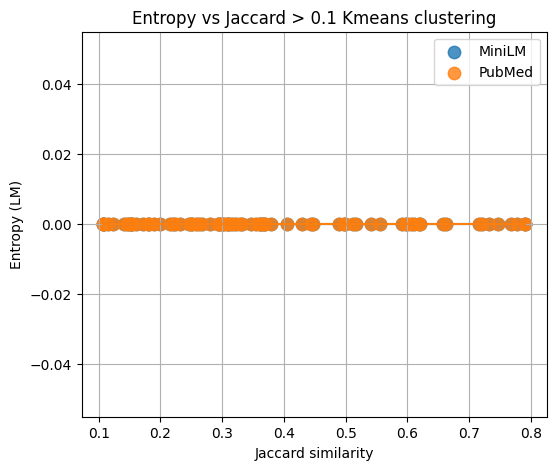

Slope LM: 0.0
R value LM: 0.0
R^2 LM: 0.0
P value LM: 1.0

Slope PubMed: 0.0
R value PubMed: 0.0
R^2 PubMed: 0.0
P value PubMed: 1.0


In [86]:
pairs_gmm = []

for i in range(len(clusters_lm_gmm)):
    j = np.argmax(jaccard_lm_pm_gmm[i])
    score = jaccard_lm_pm_gmm[i, j]

    if score > 0.1:
        pairs_gmm.append((i, j, score))

x = []
y_lm = []
y_pm = []

for i, j, score in pairs_gmm:
    x.append(score)
    y_lm.append(entropy_cluster_lm_gmm[clusters_lm_gmm[i]])
    y_pm.append(entropy_cluster_pubmed_gmm[clusters_pm_gmm[j]])

x = np.array(x, dtype=float)
y_lm = np.array(y_lm, dtype=float)
y_pm = np.array(y_pm, dtype=float)

plt.figure(figsize=(6, 5))
plt.scatter(x, y_lm, s=80, alpha=0.8)
plt.scatter(x, y_pm, s=80, alpha=0.8)

# regression
slope, intercept, r_value, p_value, std_err = linregress(x, y_lm)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x, y_pm)

# line
x_line = np.linspace(min(x), max(x), 100)
y_line_lm = slope * x_line + intercept
y_line_pm = slope_pm * x_line + intercept_pm

plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')

plt.xlabel("Jaccard similarity")
plt.ylabel("Entropy (LM)")
plt.title("Entropy vs Jaccard > 0.1 Kmeans clustering")
plt.legend(["MiniLM", "PubMed"])
plt.grid(True)
plt.show()

print("Slope LM:", slope)
print("R value LM:", r_value)
print("R^2 LM:", r_value**2)
print("P value LM:", p_value)

print("\nSlope PubMed:", slope_pm)
print("R value PubMed:", r_value_pm)
print("R^2 PubMed:", r_value_pm**2)
print("P value PubMed:", p_value_pm)

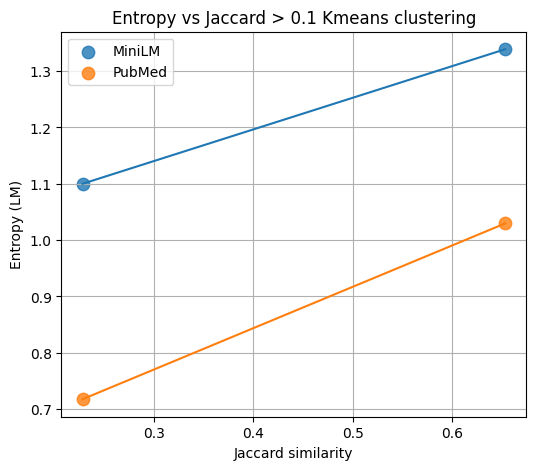

Slope LM: 0.5615423252139135
R value LM: 1.0
R^2 LM: 1.0
P value LM: 0.0

Slope PubMed: 0.733922938387846
R value PubMed: 1.0
R^2 PubMed: 1.0
P value PubMed: 0.0


In [88]:
pairs_hdbscan = []

for i in range(len(clusters_lm_hdbscan)):
    j = np.argmax(jaccard_lm_pm_hdbscan[i])
    score = jaccard_lm_pm_hdbscan[i, j]

    if score > 0.1:
        pairs_hdbscan.append((i, j, score))

x = []
y_lm = []
y_pm = []

for i, j, score in pairs_hdbscan:
    x.append(score)
    y_lm.append(entropy_cluster_lm_hdbscan[clusters_lm_hdbscan[i]])
    y_pm.append(entropy_cluster_pubmed_hdbscan[clusters_pm_hdbscan[j]])

x = np.array(x, dtype=float)
y_lm = np.array(y_lm, dtype=float)
y_pm = np.array(y_pm, dtype=float)

plt.figure(figsize=(6, 5))
plt.scatter(x, y_lm, s=80, alpha=0.8)
plt.scatter(x, y_pm, s=80, alpha=0.8)

# regression
slope, intercept, r_value, p_value, std_err = linregress(x, y_lm)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x, y_pm)

# line
x_line = np.linspace(min(x), max(x), 100)
y_line_lm = slope * x_line + intercept
y_line_pm = slope_pm * x_line + intercept_pm

plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')

plt.xlabel("Jaccard similarity")
plt.ylabel("Entropy (LM)")
plt.title("Entropy vs Jaccard > 0.1 Kmeans clustering")
plt.legend(["MiniLM", "PubMed"])
plt.grid(True)
plt.show()

print("Slope LM:", slope)
print("R value LM:", r_value)
print("R^2 LM:", r_value**2)
print("P value LM:", p_value)

print("\nSlope PubMed:", slope_pm)
print("R value PubMed:", r_value_pm)
print("R^2 PubMed:", r_value_pm**2)
print("P value PubMed:", p_value_pm)

## Cluster size vs Entropy

### MiniLM

Slope Leiden: -5.450191995111245e-06
R value Leiden: -0.015337848623751503
R^2 Leiden: 0.00023524960040511588
P value Leiden: 0.9534096581896132

Slope HDBSCAN: 4.7415010493125163e-07
R value HDBSCAN: 0.023081308766461806
R^2 HDBSCAN: 0.0005327468143727466
P value HDBSCAN: 0.9853046774557616

Slope Kmeans: -5.312804696234389e-06
R value Kmeans: -0.3831633382637994
R^2 Kmeans: 0.14681414378945876
P value Kmeans: 0.12898387450443935

Slope GMM: 0.0
R value GMM: 0.0
R^2 GMM: 0.0
P value GMM: 1.0


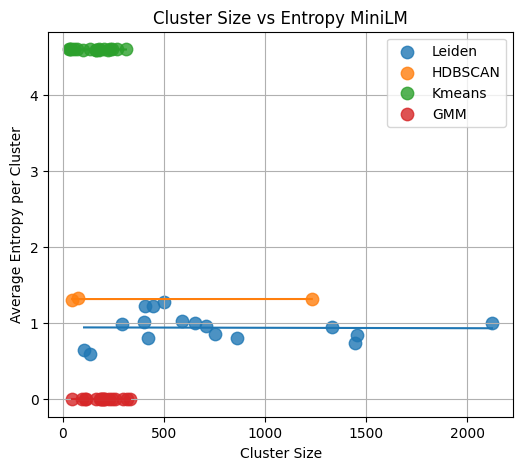

In [ ]:
x_size_lm = []
x_size_lm_hdbscan = []
x_size_lm_kmeans = []
x_size_lm_gmm = []
y_cluster_lm_leiden = []
y_cluster_lm_kmeans = []
y_cluster_lm_gmm = []
y_cluster_lm_hdbscan = []

for c in cluster_size_lm:
    if c in entropy_cluster_lm:
        x_size_lm.append(cluster_size_lm[c])
        y_cluster_lm_leiden.append(entropy_cluster_lm[c])

for c in cluster_size_lm_hdbscan:
    if c in entropy_cluster_lm_hdbscan:
        x_size_lm_hdbscan.append(cluster_size_lm_hdbscan[c])
        y_cluster_lm_hdbscan.append(entropy_lm_hdbscan[c])

for c in cluster_size_lm_kmeans:
    if c in entropy_cluster_lm_kmeans:
        x_size_lm_kmeans.append(cluster_size_lm_kmeans[c])
        y_cluster_lm_kmeans.append(entropy_lm_kmeans[c])

for c in cluster_size_lm_gmm:
    if c in entropy_cluster_lm_gmm:
        x_size_lm_gmm.append(cluster_size_lm_gmm[c])
        y_cluster_lm_gmm.append(entropy_lm_gmm[c])

slope, intercept, r_value, p_value, std_err = linregress(x_size_lm, y_cluster_lm_leiden)
slope_hdbscan, intercept_hdbscan, r_value_hdbscan, p_value_hdbscan, std_err_hdbscan = linregress(x_size_lm_hdbscan, y_cluster_lm_hdbscan)
slope_kmeans, intercept_kmeans, r_value_kmeans, p_value_kmeans, std_err_kmeans = linregress(x_size_lm_kmeans, y_cluster_lm_kmeans)
slope_gmm, intercept_gmm, r_value_gmm, p_value_gmm, std_err_gmm = linregress(x_size_lm_gmm, y_cluster_lm_gmm)

# line
x_line = np.linspace(min(x_size_lm), max(x_size_lm), 100)
y_line_lm = slope * x_line + intercept
x_line_hdbscan = np.linspace(min(x_size_lm_hdbscan), max(x_size_lm_hdbscan), 100)
y_line_lm_hdbscan = slope_hdbscan * x_line_hdbscan + intercept_hdbscan
x_line_kmeans = np.linspace(min(x_size_lm_kmeans), max(x_size_lm_kmeans), 100)
y_line_lm_kmeans = slope_kmeans * x_line_kmeans + intercept_kmeans
x_line_gmm = np.linspace(min(x_size_lm_gmm), max(x_size_lm_gmm), 100)
y_line_lm_gmm = slope_gmm * x_line_gmm + intercept_gmm

print("Slope Leiden:", slope)
print("R value Leiden:", r_value)
print("R^2 Leiden:", r_value**2)
print("P value Leiden:", p_value)

print("\nSlope HDBSCAN:", slope_hdbscan)
print("R value HDBSCAN:", r_value_hdbscan)
print("R^2 HDBSCAN:", r_value_hdbscan**2)
print("P value HDBSCAN:", p_value_hdbscan)

print("\nSlope Kmeans:", slope_kmeans)
print("R value Kmeans:", r_value_kmeans)
print("R^2 Kmeans:", r_value_kmeans**2)
print("P value Kmeans:", p_value_kmeans)

print("\nSlope GMM:", slope_gmm)
print("R value GMM:", r_value_gmm)
print("R^2 GMM:", r_value_gmm**2)
print("P value GMM:", p_value_gmm)

plt.figure(figsize=(6, 5))
plt.scatter(x_size_lm, y_cluster_lm_leiden, s=80, alpha=0.8)
plt.scatter(x_size_lm_hdbscan, y_cluster_lm_hdbscan, s=80, alpha=0.8)
plt.scatter(x_size_lm_kmeans, y_cluster_lm_kmeans, s=80, alpha=0.8)
plt.scatter(x_size_lm_gmm, y_cluster_lm_gmm, s=80, alpha=0.8)
plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line_hdbscan, y_line_lm_hdbscan, label='Fit')
plt.plot(x_line_kmeans, y_line_lm_kmeans, label='Fit')
plt.plot(x_line_gmm, y_line_lm_gmm, label='Fit')
plt.xlabel("Cluster Size")
plt.ylabel("Average Entropy per Cluster")
plt.title("Cluster Size vs Entropy MiniLM")
plt.legend(["Leiden", "HDBSCAN", "Kmeans", "GMM"])
plt.grid(True)
plt.show()

### PubMed

Slope Leiden: -5.450191995111245e-06
R value Leiden: -0.015337848623751503
R^2 Leiden: 0.00023524960040511588
P value Leiden: 0.9534096581896132

Slope HDBSCAN: 4.7415010493125163e-07
R value HDBSCAN: 0.023081308766461806
R^2 HDBSCAN: 0.0005327468143727466
P value HDBSCAN: 0.9853046774557616

Slope Kmeans: -5.312804696234389e-06
R value Kmeans: -0.3831633382637994
R^2 Kmeans: 0.14681414378945876
P value Kmeans: 0.12898387450443935

Slope GMM: 0.0
R value GMM: 0.0
R^2 GMM: 0.0
P value GMM: 1.0


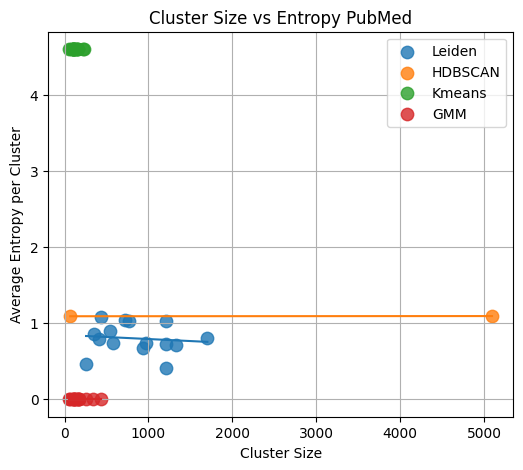

In [ ]:
x_size_pm = []
x_size_pm_hdbscan = []
x_size_pm_kmeans = []
x_size_pm_gmm = []
y_cluster_pubmed_leiden = []
y_cluster_pubmed_kmeans = []
y_cluster_pubmed_gmm = []
y_cluster_pubmed_hdbscan = []

for c in cluster_size_pubmed:
    if c in entropy_cluster_pm:
        x_size_pm.append(cluster_size_pubmed[c])
        y_cluster_pubmed_leiden.append(entropy_cluster_pm[c])

for c in cluster_size_pubmed_hdbscan:
    if c in entropy_cluster_pubmed_hdbscan:
        x_size_pm_hdbscan.append(cluster_size_pubmed_hdbscan[c])
        y_cluster_pubmed_hdbscan.append(entropy_pubmed_hdbscan[c])

for c in cluster_size_pubmed_kmeans:
    if c in entropy_cluster_pubmed_kmeans:
        x_size_pm_kmeans.append(cluster_size_pubmed_kmeans[c])
        y_cluster_pubmed_kmeans.append(entropy_cluster_pubmed_kmeans[c])

for c in cluster_size_pubmed_kmeans:
    if c in entropy_cluster_pubmed_gmm:
        x_size_pm_gmm.append(cluster_size_pubmed_gmm[c])
        y_cluster_pubmed_gmm.append(entropy_cluster_pubmed_gmm[c])

slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x_size_pm, y_cluster_pubmed_leiden)
slope_pm_hdbscan, intercept_pm_hdbscan, r_value_pm_hdbscan, p_value_pm_hdbscan, std_err_pm_hdbscan = linregress(x_size_pm_hdbscan, y_cluster_pubmed_hdbscan)
slope_pm_kmeans, intercept_pm_kmeans, r_value_pm_kmeans, p_value_pm_kmeans, std_err_pm_kmeans = linregress(x_size_pm_kmeans, y_cluster_pubmed_kmeans)
slope_pm_gmm, intercept_pm_gmm, r_value_pm_gmm, p_value_pm_gmm, std_err_pm_gmm = linregress(x_size_pm_gmm, y_cluster_pubmed_gmm)

# line
x_line = np.linspace(min(x_size_pm), max(x_size_pm), 100)
y_line_pm = slope_pm * x_line + intercept_pm
x_line_hdbscan = np.linspace(min(x_size_pm_hdbscan), max(x_size_pm_hdbscan), 100)
y_line_pm_hdbscan = slope_hdbscan * x_line_hdbscan + intercept_pm_hdbscan
x_line_kmeans = np.linspace(min(x_size_pm_kmeans), max(x_size_pm_kmeans), 100)
y_line_pm_kmeans = slope_pm_kmeans * x_line_kmeans + intercept_pm_kmeans
x_line_gmm = np.linspace(min(x_size_pm_gmm), max(x_size_pm_gmm), 100)
y_line_pm_gmm = slope_pm_gmm * x_line_gmm + intercept_pm_gmm

print("Slope Leiden:", slope)
print("R value Leiden:", r_value)
print("R^2 Leiden:", r_value**2)
print("P value Leiden:", p_value)

print("\nSlope HDBSCAN:", slope_hdbscan)
print("R value HDBSCAN:", r_value_hdbscan)
print("R^2 HDBSCAN:", r_value_hdbscan**2)
print("P value HDBSCAN:", p_value_hdbscan)

print("\nSlope Kmeans:", slope_kmeans)
print("R value Kmeans:", r_value_kmeans)
print("R^2 Kmeans:", r_value_kmeans**2)
print("P value Kmeans:", p_value_kmeans)

print("\nSlope GMM:", slope_gmm)
print("R value GMM:", r_value_gmm)
print("R^2 GMM:", r_value_gmm**2)
print("P value GMM:", p_value_gmm)

plt.figure(figsize=(6, 5))
plt.scatter(x_size_pm, y_cluster_pubmed_leiden, s=80, alpha=0.8)
plt.scatter(x_size_pm_hdbscan, y_cluster_pubmed_hdbscan, s=80, alpha=0.8)
plt.scatter(x_size_pm_kmeans, y_cluster_pubmed_kmeans, s=80, alpha=0.8)
plt.scatter(x_size_pm_gmm, y_cluster_pubmed_gmm, s=80, alpha=0.8)
plt.plot(x_line, y_line_pm, label='Fit')
plt.plot(x_line_hdbscan, y_line_pm_hdbscan, label='Fit')
plt.plot(x_line_kmeans, y_line_pm_kmeans, label='Fit')
plt.plot(x_line_gmm, y_line_pm_gmm, label='Fit')
plt.xlabel("Cluster Size")
plt.ylabel("Average Entropy per Cluster")
plt.title("Cluster Size vs Entropy PubMed")
plt.legend(["Leiden", "HDBSCAN", "Kmeans", "GMM"])
plt.grid(True)
plt.show()

Slope: -5.450191995111245e-06
R value: -0.015337848623751503
R^2: 0.00023524960040511588
P value: 0.9534096581896132


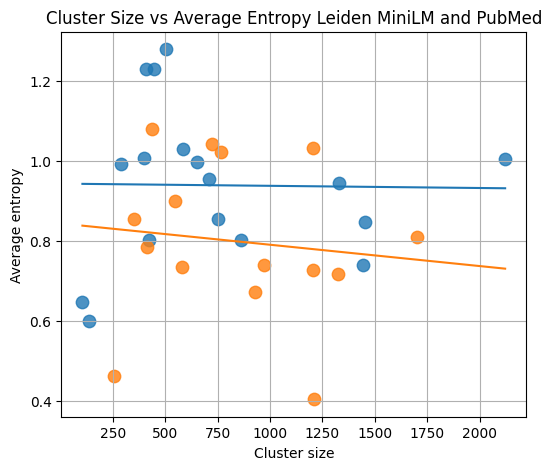

In [ ]:
slope_lm, intercept_lm, r_value_lm, p_value_lm, std_err_lm = linregress(x_size_lm, y_cluster_lm_leiden)
slope_pm, intercept_pm, r_value_pm, p_value_pm, std_err_pm = linregress(x_size_pm, y_cluster_pubmed_leiden)

# line
x_line = np.linspace(min(x_size_lm), max(x_size_lm), 100)
y_line_lm = slope_lm * x_line + intercept_lm
y_line_pm = slope_pm * x_line + intercept_pm


print("Slope:", slope)
print("R value:", r_value)
print("R^2:", r_value**2)
print("P value:", p_value)

plt.figure(figsize=(6, 5))

plt.scatter(x_size_lm, y_cluster_lm_leiden, s=80, alpha=0.8)
plt.scatter(x_size_pm, y_cluster_pubmed_leiden, s=80, alpha=0.8)
plt.plot(x_line, y_line_lm, label='Fit')
plt.plot(x_line, y_line_pm, label='Fit')
plt.xlabel("Cluster size")
plt.ylabel("Average entropy")
plt.title("Cluster Size vs Average Entropy Leiden MiniLM and PubMed")
plt.grid(True)
plt.show()

## Average entropy for MiniLM and PubMed using different clustering methods

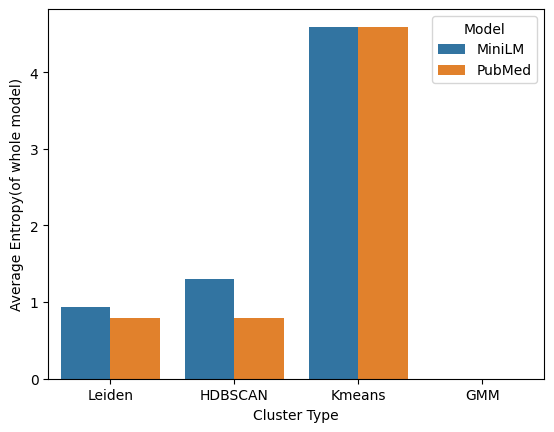

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Cluster Type": [
        "Leiden", "Leiden",
        "HDBSCAN", "HDBSCAN",
        "Kmeans", "Kmeans",
        "GMM", "GMM"
    ],
    "Model": [
        "MiniLM", "PubMed",
        "MiniLM", "PubMed",
        "MiniLM", "PubMed",
        "MiniLM", "PubMed"
    ],
    "Average Entropy(of whole model)": [
        0.93797, 0.78928,
        1.3062, 0.78928,
        4.5927, 4.5926,
        0, 0
    ]
})

sns.barplot(data=df, x="Cluster Type", y="Average Entropy(of whole model)", hue="Model")
plt.show()

### Tree similarity

In [ ]:
import requests
import obonet

url = "https://www.informatics.jax.org/downloads/reports/MPheno_OBO.ontology"
r = requests.get(url)

with open("../data/mouse_ontology_files/mp.obo", "wb") as f:
    f.write(r.content)

graph = obonet.read_obo("../data/mouse_ontology_files/mp.obo")

# find nodes with multiple parents
multi_parent_nodes = [
    n for n, data in graph.nodes(data=True)
    if 'is_a' in data and len(data['is_a']) > 1
]

print(len(multi_parent_nodes))

In [ ]:
# get name:____ from obo 
mp_names = []
for node_id, data in graph.nodes(data=True):
    name = data.get("name")
    if name:
        mp_names.append(name.lower())

print(mp_names)

['mammalian phenotype', 'abnormal adipose tissue morphology', 'increased brown adipose tissue amount', 'increased white adipose tissue amount', 'abnormal abdominal fat pad morphology', 'abnormal adipose tissue distribution', 'abnormal ear pigmentation', 'big ears', 'small ears', 'thick ears', 'scaly ears', 'prominent ears', 'abnormal ear shape', 'abnormal ear position', 'lowered ear position', 'otic hypertelorism', 'abnormal inner ear morphology', 'abnormal pars superior vestibularis morphology', 'abnormal malleus morphology', 'abnormal tympanic ring morphology', 'abnormal cochlea morphology', 'cochlear degeneration', 'absent scala media', 'abnormal inner ear vestibule morphology', 'abnormal membranous labyrinth morphology', 'absent semicircular canals', 'abnormal lateral semicircular canal morphology', 'abnormal otic capsule morphology', 'decreased middle ear ossicle number', 'absent endolymphatic duct', 'abnormal organ of corti morphology', 'organ of corti degeneration', 'absent orga

### compare ontology DAG names to txt file phenotype names used

In [ ]:
with open("../data/mouse_files/gene_set_list_mouse_2024_clean.txt", "r") as f:
    phenotypes = f.readlines()

matches = sum(name.strip().lower() in mp_names for name in phenotypes)
print("Exact MP matches:", matches, "out of", len(phenotypes))

Exact MP matches: 10687 out of 12624
